In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import nltk
#nltk.download('vader_lexicon')
#nltk.download('punkt')
#nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import string
from scipy.stats import spearmanr
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
#!pip install xgboost
#!pip install keras-tuner --quiet
from keras_tuner.tuners import RandomSearch
from xgboost import XGBRegressor
from scipy.stats import pearsonr

In [2]:
# Load tweet data
amzn_price = pd.read_csv("stockprice/AMZN.csv")
tweets = pd.read_csv("stocktweet/stocktweet.csv")

In [3]:
amzn_price.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2019-12-31,92.099998,92.663002,91.611504,92.391998,92.391998,50130000
1,2020-01-02,93.750000,94.900497,93.207497,94.900497,94.900497,80580000
2,2020-01-03,93.224998,94.309998,93.224998,93.748497,93.748497,75288000
3,2020-01-06,93.000000,95.184502,93.000000,95.143997,95.143997,81236000
4,2020-01-07,95.224998,95.694504,94.601997,95.343002,95.343002,80898000


In [4]:
amzn_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       254 non-null    object 
 1   Open       254 non-null    float64
 2   High       254 non-null    float64
 3   Low        254 non-null    float64
 4   Close      254 non-null    float64
 5   Adj Close  254 non-null    float64
 6   Volume     254 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 14.0+ KB


In [5]:
amzn_price.describe()

,Open,High,Low,Close,Adj Close,Volume
count,254.000000,254.000000,254.000000,254.000000,254.000000,2.540000e+02
mean,133.885051,135.677053,131.953638,133.878775,133.878775,9.842891e+07
std,27.629617,27.792147,27.046226,27.359174,27.359174,3.956220e+07
min,82.075500,87.972504,81.301498,83.830498,83.830498,2.903800e+07
25%,106.465124,108.039877,104.851376,106.931000,106.931000,6.937200e+07
50%,142.162498,146.264000,140.625000,144.224998,144.224998,9.038800e+07
75%,158.976871,160.092003,156.518379,158.250496,158.250496,1.157840e+08
max,177.350006,177.612503,174.334503,176.572495,176.572495,3.113460e+08


In [6]:
tweets.head()

,id,date,ticker,tweet
0,100001,01/01/2020,AMZN,$AMZN Dow futures up by 100 points already 🥳
1,100002,01/01/2020,TSLA,$TSLA Daddy's drinkin' eArly tonight! Here's t...
2,100003,01/01/2020,AAPL,$AAPL We’ll been riding since last December fr...
3,100004,01/01/2020,TSLA,"$TSLA happy new year, 2020, everyone🍷🎉🙏"
4,100005,01/01/2020,TSLA,"$TSLA haha just a collection of greats...""Mars..."


In [7]:
tweets.tail()

,id,date,ticker,tweet
9995,109996,31/12/2020,ABNB,"$ABNB “sugar daddy puts.” Don’t mind me, I’m j..."
9996,109997,31/12/2020,TSLA,$TSLA \nGood news... now bears can get help wh...
9997,109998,31/12/2020,BABA,$BABA Who else is glad they sold in 240s yeste...
9998,109999,31/12/2020,CCL,$CCL $23 calls for .79 you know what to do 🥳
9999,110000,31/12/2020,TSLA,$TSLA 🔥 closed out 15k in profit!Happy New Ye...


Tweets span the year 2020

In [9]:
tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10000 non-null  int64 
 1   date    10000 non-null  object
 2   ticker  10000 non-null  object
 3   tweet   10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [10]:
tweets.describe()

,id
count,10000.00000
mean,105000.50000
std,2886.89568
min,100001.00000
25%,102500.75000
50%,105000.50000
75%,107500.25000
max,110000.00000


## Choosing companies to explore further
- count how many tweets refer to each company

ticker
TSLA    4341
AAPL    1721
BA       919
DIS      432
AMZN     407
MSFT     271
CCL      264
BABA     239
FB       204
NFLX     195
Name: count, dtype: int64


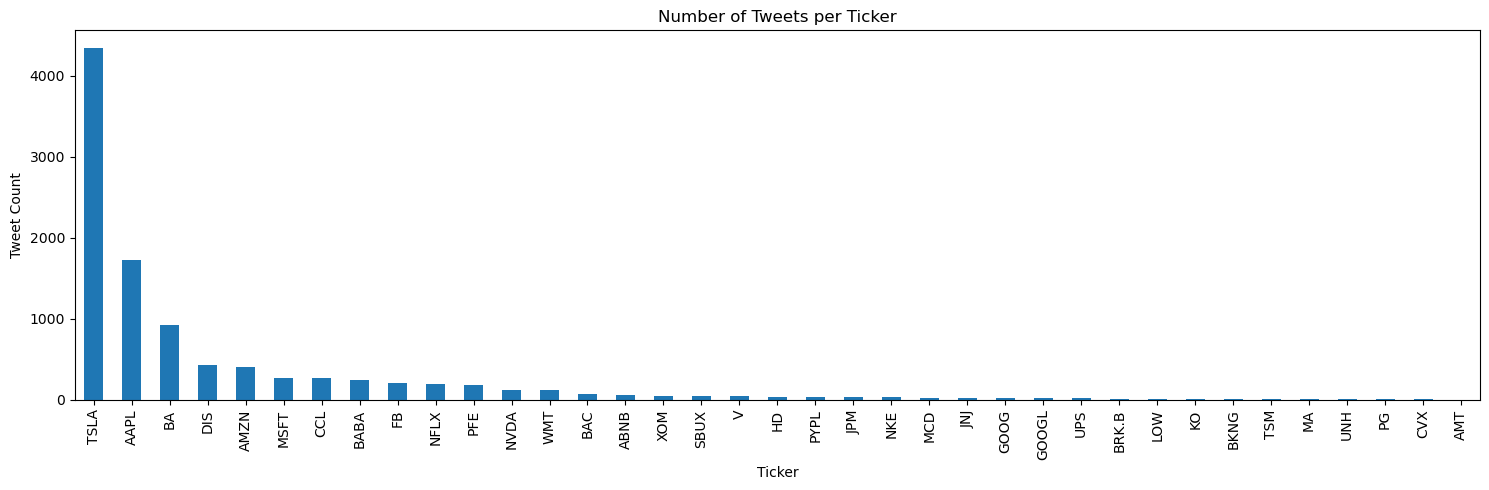

In [12]:
# Count tweets per ticker
tweet_counts = tweets['ticker'].value_counts()

# Display the top 10 tickers
print(tweet_counts.head(10))

# Optional: plot the distribution
tweet_counts.plot(kind='bar', figsize=(15, 5), title="Number of Tweets per Ticker")
plt.xlabel("Ticker")
plt.ylabel("Tweet Count")
plt.tight_layout()
plt.show()

Looking at what data is available for AMZN

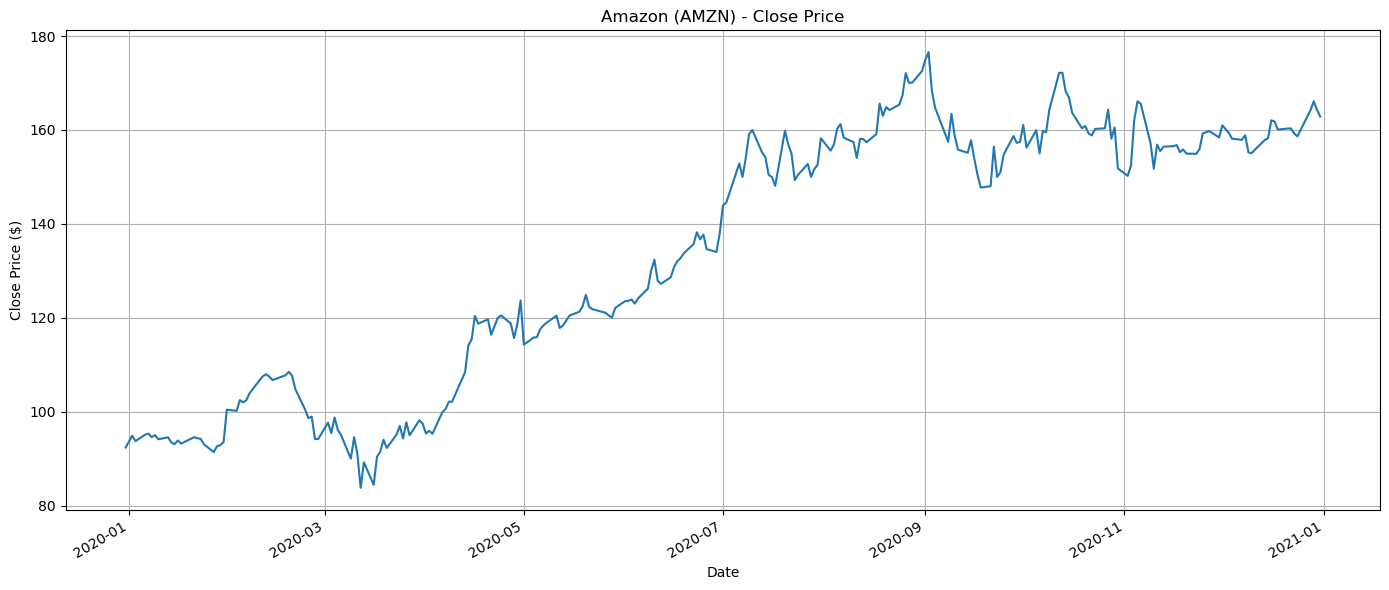

In [14]:
# Convert 'Date' to datetime format... currently object
amzn_price['Date'] = pd.to_datetime(amzn_price['Date'])

# Set date as index 
amzn_price.set_index('Date', inplace=True)

# Plot Close price
plt.figure(figsize=(14, 6))
amzn_price['Close'].plot(title="Amazon (AMZN) - Close Price")
plt.ylabel("Close Price ($)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

Both the tweets and the stock prices cover the year 2020. Let's look at how many dates for amazon tweets overlap with amazon stock prices

In [16]:
#set date for tweets to datetime format
tweets['date'] = pd.to_datetime(tweets['date'], errors='coerce')

#get amazon only tweets
amzn_tweets = tweets[tweets['ticker'] == 'AMZN']

In [17]:
amzn_tweets.head()

,id,date,ticker,tweet
0,100001,2020-01-01,AMZN,$AMZN Dow futures up by 100 points already 🥳
21,100022,2020-03-01,AMZN,$AMZN who ever shorted today will be deported ...
29,100030,2020-06-01,AMZN,$AMZN I hope we can come close to touching 200...
52,100053,2020-07-01,AMZN,$AMZN CONGRATS TO ALL THE LONG - there were so...
95,100096,2020-09-01,AMZN,$AMZN Now it’s moving with the market 😂


In [18]:
# resetting index so 'Date' becomes a column again
amzn_price.reset_index(inplace=True)

In [19]:
# Get unique dates for each dataset
stock_dates = set(amzn_price['Date'].dt.date.unique())
tweet_dates = set(amzn_tweets['date'].dt.date.unique())

# Find how many of these dates overlap for tweets and stock, for use in exogeneous modelling later
shared_dates = stock_dates.intersection(tweet_dates)
print(f" Shared Dates: {len(shared_dates)} out of {len(stock_dates)} trading days")

 Shared Dates: 55 out of 254 trading days


In [20]:
# get list of overlapping dates
full_amzn_dates = sorted(shared_dates)

# Create a DataFrame to display asa list
full_amzn_df = pd.DataFrame(full_amzn_dates, columns=['Shared Date'])

# print list
print(full_amzn_df.to_string(index=False))

Shared Date
 2020-01-02
 2020-01-07
 2020-01-08
 2020-01-09
 2020-01-10
 2020-02-03
 2020-02-05
 2020-02-06
 2020-02-07
 2020-02-10
 2020-02-12
 2020-03-03
 2020-03-06
 2020-03-12
 2020-04-02
 2020-04-03
 2020-04-06
 2020-04-09
 2020-05-05
 2020-05-08
 2020-05-11
 2020-06-01
 2020-06-02
 2020-06-03
 2020-06-05
 2020-06-08
 2020-06-10
 2020-06-11
 2020-07-01
 2020-07-02
 2020-07-07
 2020-07-08
 2020-07-10
 2020-08-05
 2020-08-07
 2020-08-10
 2020-08-12
 2020-09-01
 2020-09-11
 2020-10-01
 2020-10-02
 2020-10-06
 2020-10-07
 2020-10-09
 2020-10-12
 2020-11-02
 2020-11-03
 2020-11-06
 2020-11-09
 2020-11-11
 2020-11-12
 2020-12-02
 2020-12-03
 2020-12-08
 2020-12-10


Only have tweets for about 20% of AMZN dates, will look at this for other companies too to see how they compare.

Looking at the gaps between the dates to see if there is any consistent pattern so that data can be taken at regular intervals for ARIMA models etc

In [23]:
full_amzn_df['Shared Date'] = pd.to_datetime(full_amzn_df['Shared Date'])
full_amzn_df['Gap (days)'] = full_amzn_df['Shared Date'].diff().dt.days

In [24]:
print(full_amzn_df)

   Shared Date  Gap (days)
0   2020-01-02         NaN
1   2020-01-07         5.0
2   2020-01-08         1.0
3   2020-01-09         1.0
4   2020-01-10         1.0
5   2020-02-03        24.0
6   2020-02-05         2.0
7   2020-02-06         1.0
8   2020-02-07         1.0
9   2020-02-10         3.0
10  2020-02-12         2.0
11  2020-03-03        20.0
12  2020-03-06         3.0
13  2020-03-12         6.0
14  2020-04-02        21.0
15  2020-04-03         1.0
16  2020-04-06         3.0
17  2020-04-09         3.0
18  2020-05-05        26.0
19  2020-05-08         3.0
20  2020-05-11         3.0
21  2020-06-01        21.0
22  2020-06-02         1.0
23  2020-06-03         1.0
24  2020-06-05         2.0
25  2020-06-08         3.0
26  2020-06-10         2.0
27  2020-06-11         1.0
28  2020-07-01        20.0
29  2020-07-02         1.0
30  2020-07-07         5.0
31  2020-07-08         1.0
32  2020-07-10         2.0
33  2020-08-05        26.0
34  2020-08-07         2.0
35  2020-08-10         3.0
3

looks like I could do a monthly value, some very large gaps between dates

## Getting info on BOEING

In [27]:
#get Boeing only tweets
ba_tweets = tweets[tweets['ticker'] == 'BA']

In [28]:
ba_tweets.head()

,id,date,ticker,tweet
44,100045,2020-07-01,BA,$BA Stocks usually look bearish until they do...
105,100106,2020-10-01,BA,$BA BOEING is a bear proof stock. 😂
107,100108,2020-10-01,BA,$BA new CEO already cleaning out the dirty lau...
112,100113,2020-10-01,BA,$BA that email leaked was a huge nothing burge...
114,100115,2020-10-01,BA,$BA about to explode 🚨\nKeep shorting please


In [29]:
ba_tweets.info()

<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, 44 to 9960
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   id      919 non-null    int64         
 1   date    332 non-null    datetime64[ns]
 2   ticker  919 non-null    object        
 3   tweet   919 non-null    object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 35.9+ KB


In [30]:
ba_price = pd.read_csv("stockprice/BA.csv")

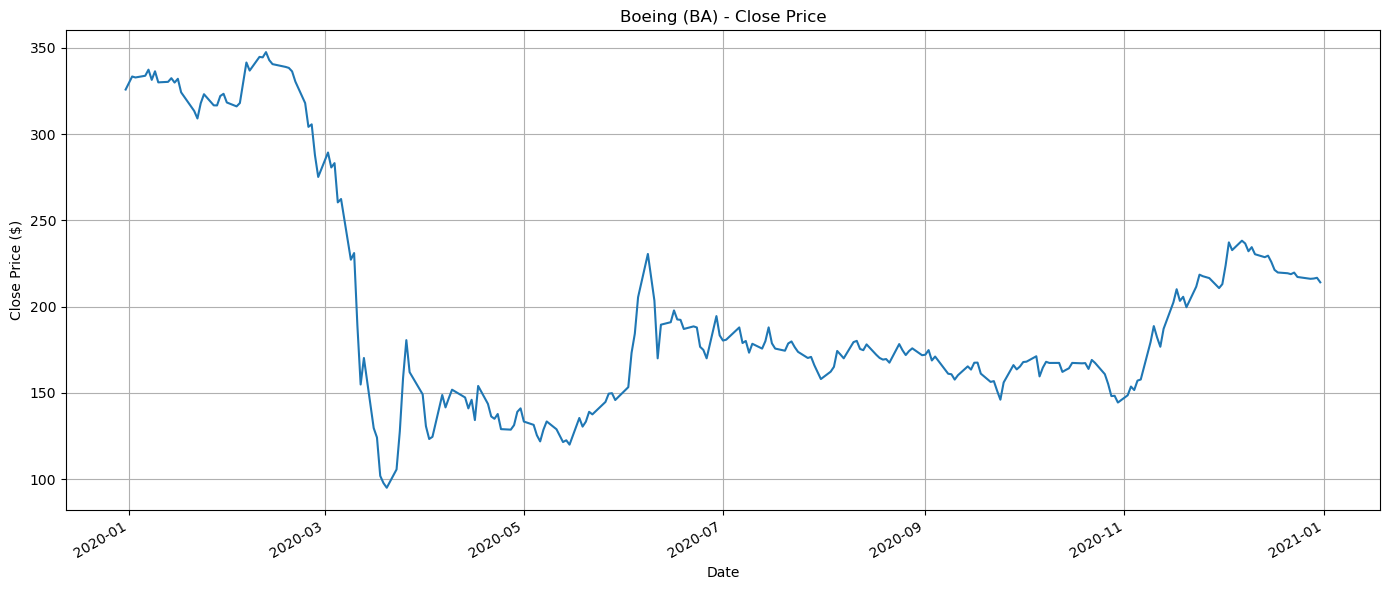

In [31]:
# Convert 'Date' to datetime format... currently object
ba_price['Date'] = pd.to_datetime(ba_price['Date'])

# Set date as index 
ba_price.set_index('Date', inplace=True)

# Plot Close price
plt.figure(figsize=(14, 6))
ba_price['Close'].plot(title="Boeing (BA) - Close Price")
plt.ylabel("Close Price ($)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# resetting index so 'Date' becomes a column again
ba_price.reset_index(inplace=True)

In [33]:
# Get unique dates for each dataset
stock_dates = set(ba_price['Date'].dt.date.unique())
tweet_dates = set(ba_tweets['date'].dt.date.unique())

# Find how many of these dates overlap for tweets and stock, for use in exogeneous modelling later
shared_dates = stock_dates.intersection(tweet_dates)
print(f" Shared Dates: {len(shared_dates)} out of {len(stock_dates)} trading days")

 Shared Dates: 54 out of 254 trading days


In [34]:
# get list of overlapping dates
ba_dates = sorted(shared_dates)

# Create a DataFrame to display asa list
ba_df = pd.DataFrame(ba_dates, columns=['Shared Date'])

# print list
#print(ba_df.to_string(index=False))

In [35]:
#look at boeing gaps
ba_df['Shared Date'] = pd.to_datetime(ba_df['Shared Date'])
ba_df['Gap (days)'] = ba_df['Shared Date'].diff().dt.days

print(ba_df)

   Shared Date  Gap (days)
0   2020-01-07         NaN
1   2020-01-10         3.0
2   2020-02-04        25.0
3   2020-02-05         1.0
4   2020-02-06         1.0
5   2020-02-07         1.0
6   2020-02-10         3.0
7   2020-02-12         2.0
8   2020-03-04        21.0
9   2020-03-06         2.0
10  2020-03-09         3.0
11  2020-03-12         3.0
12  2020-04-03        22.0
13  2020-04-06         3.0
14  2020-04-08         2.0
15  2020-04-09         1.0
16  2020-05-05        26.0
17  2020-05-06         1.0
18  2020-05-08         2.0
19  2020-06-02        25.0
20  2020-06-03         1.0
21  2020-06-04         1.0
22  2020-06-05         1.0
23  2020-06-08         3.0
24  2020-06-10         2.0
25  2020-07-01        21.0
26  2020-07-02         1.0
27  2020-07-07         5.0
28  2020-07-08         1.0
29  2020-07-10         2.0
30  2020-08-04        25.0
31  2020-08-06         2.0
32  2020-08-07         1.0
33  2020-08-10         3.0
34  2020-08-12         2.0
35  2020-09-04        23.0
3

In [36]:
# same issue again.

### Adding in files from VM, Spark
- File containes tweet and stock data for the top 9 companies with highest tweet volume.

In [38]:
#finding file
folder_path = os.path.join("datasets_VM", "merged_top9_local")
#match three files
all_files = glob.glob(os.path.join(folder_path, "part-*.csv"))
#read in and merge to one file
df_merged = pd.concat((pd.read_csv(file) for file in all_files), ignore_index=True)

In [39]:
# check file structure
print(df_merged.head())
print(df_merged.info())

         date ticker       open       high        low      close  adj_close  \
0  2019-12-31   TSLA  27.000000  28.086000  26.805332  27.888666  27.888666   
1  2020-01-02   TSLA  28.299999  28.713333  28.114000  28.684000  28.684000   
2  2020-01-03   TSLA  29.366667  30.266666  29.128000  29.534000  29.534000   
3  2020-01-03   TSLA  29.366667  30.266666  29.128000  29.534000  29.534000   
4  2020-01-03   TSLA  29.366667  30.266666  29.128000  29.534000  29.534000   

      volume        id                                              tweet  
0  154285500       NaN                                                NaN  
1  142981500  108002.0  $TSLA Hate to say I called it, but I called it...  
2  266677500  100025.0  $TSLA Ignore the clowns and bears!  Marvelous ...  
3  266677500  100024.0  $TSLA  can one hear the bear as it cries in th...  
4  266677500  100023.0  $TSLA 🐻 not see anything like this with Tesla ...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9346 entries, 0 to 

In [40]:
#function for saving file to csv for use in Dashboard later
def save_forecast_to_csv(df_pred, ticker, model_name, horizon):
    df_pred = df_pred.copy()
    df_pred['ticker'] = ticker
    df_pred['model'] = model_name
    df_pred['horizon'] = horizon

    os.makedirs("forecast_exports", exist_ok=True)
    filename = f"forecast_exports/{ticker}_{model_name}_{horizon}d.csv"
    df_pred.to_csv(filename, index=True)
    print(f"Saved: {filename}")

In [41]:
#function for saving ARIMA type forecasts with stock and sentiment ro improve dashboard
def save_arima_forecast_with_stock(preds_df, ticker, model_name, horizon):
    #filter for the selected ticker
    df_filtered = df_merged[df_merged['ticker'] == ticker].copy()
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])
    df_filtered.set_index('date', inplace=True)

    #starting with date and close
    df_full = pd.DataFrame({
        'date': df_filtered.index,
        'close': df_filtered['close'],
    })

    # adding both sentiment columns if they exist
    if 'weekly_sentiment' in df_filtered.columns:
        df_full['weekly_sentiment'] = df_filtered['weekly_sentiment'].values
    if 'daily_sentiment' in df_filtered.columns:
        df_full['daily_sentiment'] = df_filtered['daily_sentiment'].values

    # empty column for forecast 
    col_name = f"{model_name}_{horizon}d"
    df_full[col_name] = np.nan

    # lining up forecasts to matching dates
    for idx, row in preds_df.iterrows():
        forecast_date = row['forecast_made_on'] + pd.Timedelta(days=row['day_ahead'])
        match = df_full['date'] == forecast_date
        df_full.loc[match, col_name] = row['forecast']

    # Save to CSV
    os.makedirs("forecast_exports", exist_ok=True)
    df_full.to_csv(f"forecast_exports/{ticker}_{model_name}_{horizon}d_full.csv", index=False)
    print(f"Saved full timeline with forecast: forecast_exports/{ticker}_{model_name}_{horizon}d_full.csv")

In [42]:
#function for saving LSTM/XGBOOST in similar way to above.. but allowing for rolling forcasts
def save_lstm_rolling_forecast_with_stock(
    y_true_rescaled,
    y_pred_rescaled,
    ticker,
    model_name,
    horizon,
    window_dates,
    start_idx,
    n_preds,
    tuned=False  #so can include models with hyperameter tuning 
):
    #filtering for required ticker 
    df_filtered = df_merged[df_merged['ticker'] == ticker].copy()
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])
    df_filtered.set_index('date', inplace=True)

    #building base timeline
    df_full = pd.DataFrame({
        'date': df_filtered.index,
        'close': df_filtered['close'],
    })

    #include both sentiment types if present for adding to plots as overlay
    if 'weekly_sentiment' in df_filtered.columns:
        df_full['weekly_sentiment'] = df_filtered['weekly_sentiment'].values
    if 'daily_sentiment' in df_filtered.columns:
        df_full['daily_sentiment'] = df_filtered['daily_sentiment'].values

    #collecting rolling forecast results
    records = []

    for i in range(n_preds):
        made_on = window_dates[start_idx + i]
        for day in range(horizon):
            try:
                record = {
                    'forecast_made_on': made_on,
                    'day_ahead': day + 1,
                    'forecast': y_pred_rescaled[i][day],
                    'actual': y_true_rescaled[i][day],
                    'ticker': ticker,
                    'model': model_name,
                    'horizon': horizon,
                }
                records.append(record)
            except:
                continue

    df_preds = pd.DataFrame(records)

    #getting the date of the forecasted value
    df_preds['forecast_date'] = df_preds.apply(
        lambda row: row['forecast_made_on'] + pd.Timedelta(days=row['day_ahead']),
        axis=1
    )

    #merging forecast into the full timeline
    for i, row in df_preds.iterrows():
        col_name = f"{row['model']}_{row['horizon']}d"
        if col_name not in df_full.columns:
            df_full[col_name] = np.nan
        match_idx = df_full['date'] == row['forecast_date']
        df_full.loc[match_idx, col_name] = row['forecast']

    #save
    os.makedirs("forecast_exports", exist_ok=True)
    suffix = "_tuned" if tuned else ""
    save_path = f"forecast_exports/{ticker}_{model_name}_{horizon}d_full{suffix}.csv"
    df_full.to_csv(save_path, index=False)
    print(f"Saved full timeline with forecast: {save_path}")


### Sentiment analysis on tweets

In [44]:
#preprocessing tweets
stop_words = set(stopwords.words('english'))

#defining preprocessing funcion
def preprocess_tweet(tweet):
    # get to lowercase
    tweet = tweet.lower()
    # tokenize tweets
    tokens = word_tokenize(tweet)
    # remove punctuation and stopwords
    tokens = [t for t in tokens if t not in string.punctuation and t not in stop_words]
    # re-join for VADER
    return " ".join(tokens)

#applying the preprocessing and fill n/a values
df_merged['tweet'] = df_merged['tweet'].fillna("")
df_merged['clean_tweet'] = df_merged['tweet'].apply(preprocess_tweet)

In [45]:
#configure VADER
sia = SentimentIntensityAnalyzer()

#applying VADER sentiment analysis to cleaned tweets
df_merged['sentiment'] = df_merged['clean_tweet'].apply(lambda x: sia.polarity_scores(x)['compound'])

#labelling the sentiment s positive/netural/ negative
df_merged['sentiment_label'] = df_merged['sentiment'].apply(
    lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral')
)

In [46]:
#fixing issue with aggegation which cause flat sections in stock data later... ill restart kernel after
# ensure date is in date time format
df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce')
tweet_sentiment = df_merged[['ticker', 'date', 'sentiment']].dropna()

# DAILY sentiment
daily_sentiment = tweet_sentiment.groupby(['ticker', 'date'])['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'sentiment': 'daily_sentiment'}, inplace=True)

# WEEKLY sentiment
tweet_sentiment['week'] = tweet_sentiment['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_sentiment = tweet_sentiment.groupby(['ticker', 'week'])['sentiment'].mean().reset_index()
weekly_sentiment.rename(columns={'sentiment': 'weekly_sentiment'}, inplace=True)

In [47]:
#rebuilding proper stock data from df_merged (messed this up last time)
stock_cols = ['date', 'ticker', 'open', 'high', 'low', 'close', 'adj_close', 'volume']
stock_df = df_merged[stock_cols].drop_duplicates()
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df['week'] = stock_df['date'].dt.to_period('W').dt.start_time

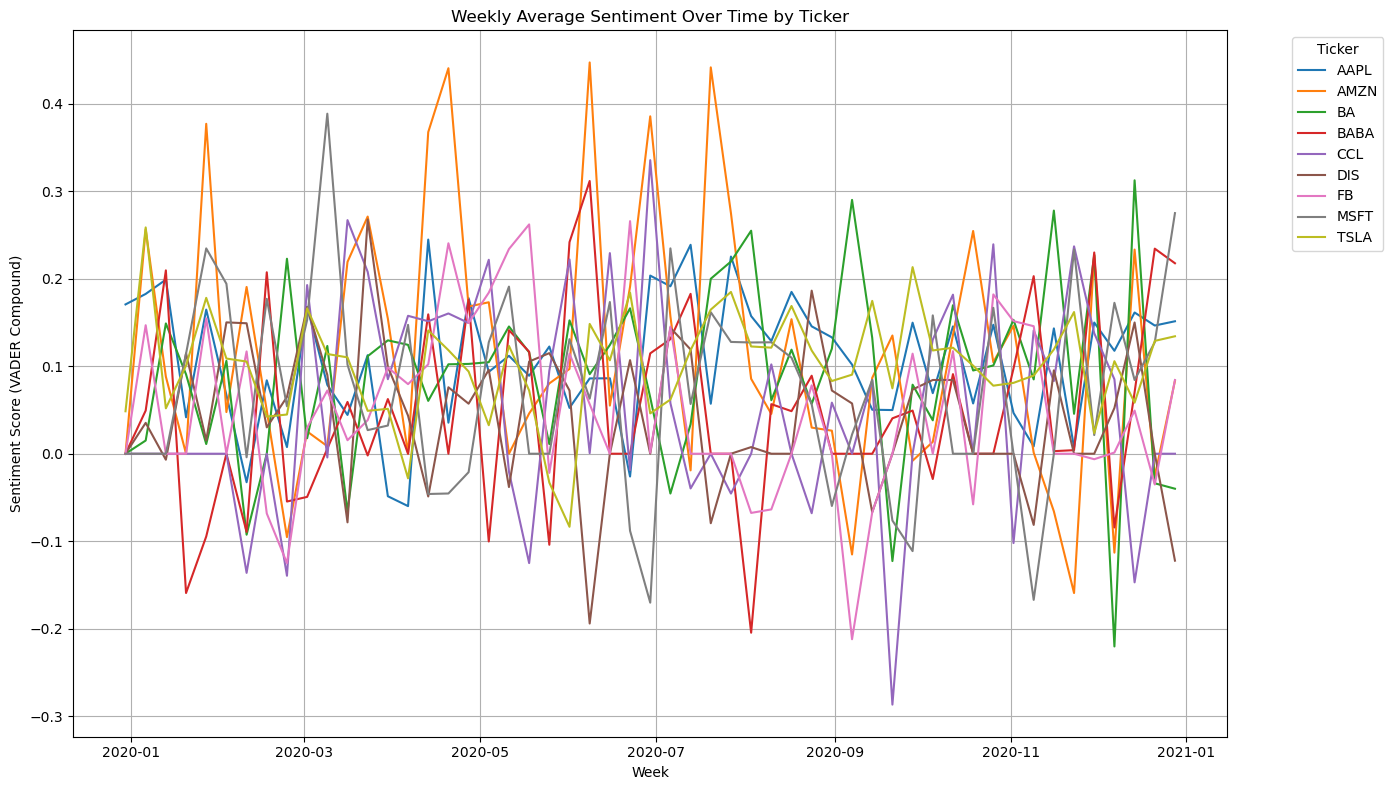

In [48]:
#visualising sentiment 
weekly_sentiment['week'] = pd.to_datetime(weekly_sentiment['week'])#checking week is date time

plt.figure(figsize=(14, 8))

# plot each ticker with a different color
for ticker in weekly_sentiment['ticker'].unique():
    subset = weekly_sentiment[weekly_sentiment['ticker'] == ticker]
    plt.plot(subset['week'], subset['weekly_sentiment'], label=ticker)

# getting labels etc
plt.title('Weekly Average Sentiment Over Time by Ticker')
plt.xlabel('Week')
plt.ylabel('Sentiment Score (VADER Compound)')
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

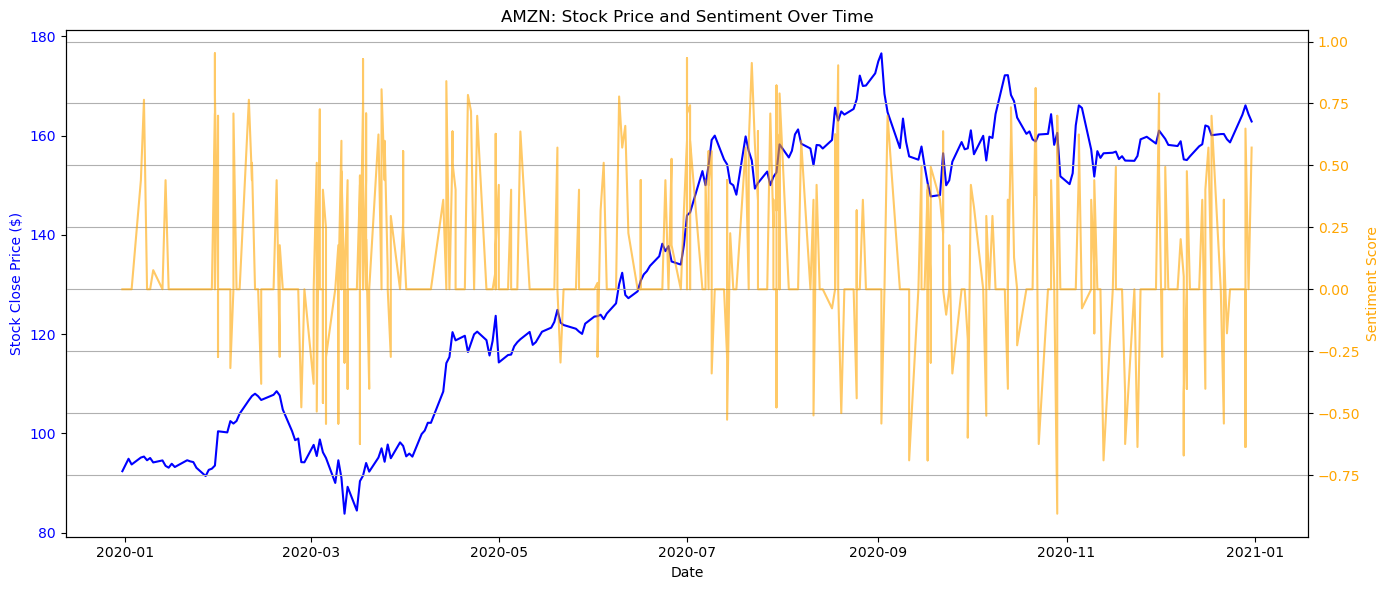

In [49]:
#plotting stcok data for Amazon alongside it's sentiment 
#to see if there appears to be any shared pattern

selected_ticker = 'AMZN'#I will swap this out for different companies

# filtering data 
stock_data = df_merged[df_merged['ticker'] == selected_ticker].copy()

# ensuring datetime
stock_data['date'] = pd.to_datetime(stock_data['date'])

# Create plot
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot stock Close price (left Y-axis)
ax1.plot(stock_data['date'], stock_data['close'], color='blue', label='Close Price')
ax1.set_xlabel('Date')
ax1.set_ylabel('Stock Close Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second Y-axis for sentiment... maybe scale values...
ax2 = ax1.twinx()
ax2.plot(stock_data['date'], stock_data['sentiment'], color='orange', label='Sentiment (VADER)', alpha=0.6)
ax2.set_ylabel('Sentiment Score', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and layout
plt.title(f'{selected_ticker}: Stock Price and Sentiment Over Time')
fig.tight_layout()
plt.grid(True)
plt.show()

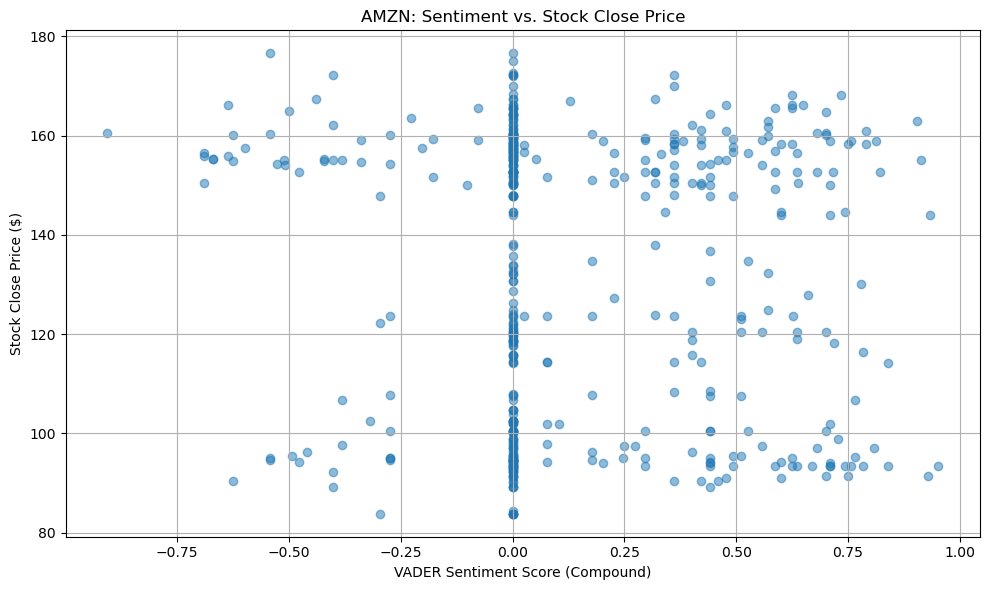

In [50]:
#getting a scatter plot for same to better see relationship
# dropingp rows missing either value
stock_data = stock_data.dropna(subset=['close', 'sentiment'])

# plotting
plt.figure(figsize=(10, 6))
plt.scatter(stock_data['sentiment'], stock_data['close'], alpha=0.5)
plt.title(f'{selected_ticker}: Sentiment vs. Stock Close Price')
plt.xlabel('VADER Sentiment Score (Compound)')
plt.ylabel('Stock Close Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# dropping nulls
filtered_data = stock_data.dropna(subset=['close', 'sentiment'])

# calculate Pearson r and p-value
r, p_value = pearsonr(filtered_data['sentiment'], filtered_data['close'])

print(f"Pearson correlation (r) between sentiment and Close price for {selected_ticker}: {r:.4f}")
print(f"P-value: {p_value:.4f}") # how likely this correlation value appeared by random chance

Pearson correlation (r) between sentiment and Close price for AMZN: -0.0565
P-value: 0.2144


Relatonship not very obvious... no surprising given there was not alot of tweets for each day

will how more tickers plots in dashboard (a select company dropdown option so that the plot off al sentiments is less crowded and an option to overlay sentiment plots also, and display when hover)

In [53]:
#getting weekly sentiment into df_merged dataframe so this can be explored with the stock data
#making sure date is in datetime
df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce')
df_merged['week'] = df_merged['date'].dt.to_period('W').dt.start_time

# grouping to get weekly average sentiment
weekly_sentiment = df_merged.groupby(['ticker', 'week'])['sentiment'].mean().reset_index()
weekly_sentiment.rename(columns={'sentiment': 'weekly_sentiment'}, inplace=True)

# merging it in
df_merged = pd.merge(df_merged, weekly_sentiment, on=['ticker', 'week'], how='left')

#forward fill sentiment values by ticker
df_merged.sort_values(['ticker', 'date'], inplace=True)
df_merged['weekly_sentiment'] = df_merged.groupby('ticker')['weekly_sentiment'].ffill()

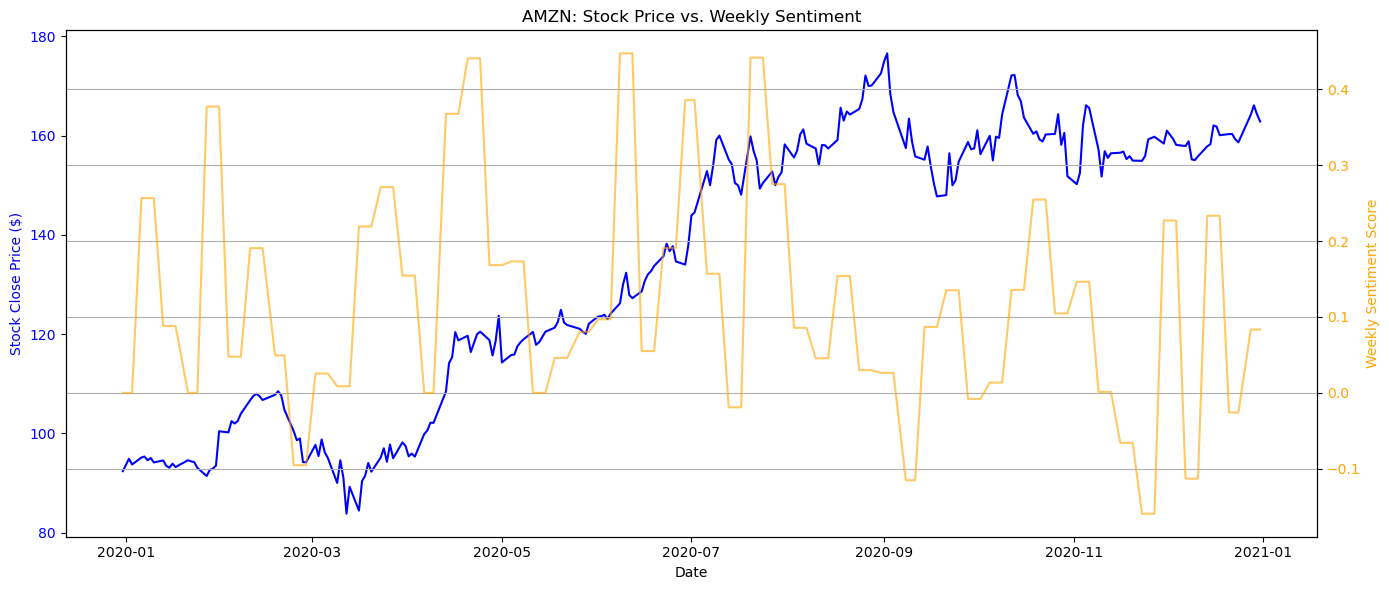

In [54]:
#doing plots with weekly sentiment
# choosing ticker... can swap out ticker later
selected_ticker = 'AMZN'
stock_data = df_merged[df_merged['ticker'] == selected_ticker].copy()
stock_data['date'] = pd.to_datetime(stock_data['date'])

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(stock_data['date'], stock_data['close'], color='blue', label='Close Price')
ax1.set_ylabel('Stock Close Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(stock_data['date'], stock_data['weekly_sentiment'], color='orange', label='Weekly Sentiment', alpha=0.6)
ax2.set_ylabel('Weekly Sentiment Score', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title(f'{selected_ticker}: Stock Price vs. Weekly Sentiment')
fig.tight_layout()
plt.grid(True)
plt.show()#plot much clearer now

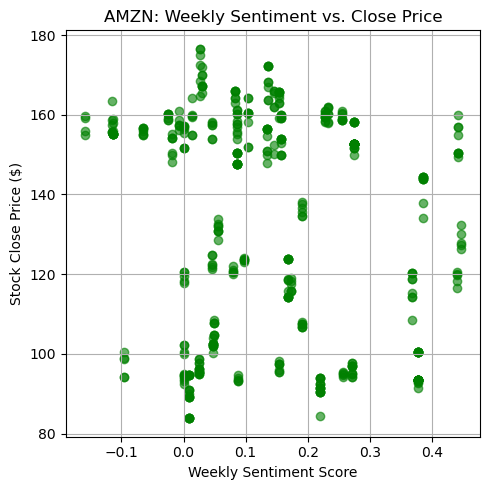

In [55]:
#scatterplot with weekly sentiment
plt.figure(figsize=(5, 5))
plt.scatter(stock_data['weekly_sentiment'], stock_data['close'], alpha=0.6, color='green')
plt.title(f'{selected_ticker}: Weekly Sentiment vs. Close Price')
plt.xlabel('Weekly Sentiment Score')
plt.ylabel('Stock Close Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
# calculating correlation
r, p = pearsonr(stock_data['weekly_sentiment'], stock_data['close'])

print(f"Pearson correlation (r) between weekly sentiment and close price for {selected_ticker}: {r:.4f}")
print(f"P-value: {p:.4f}")

Pearson correlation (r) between weekly sentiment and close price for AMZN: -0.1414
P-value: 0.0018


Value is actually significant this time, with weekly sentiment, still weak correlation.
Will repeat plots for Boeing too before choosing which 5 companies I will use for Time Series analysis 

In [58]:
r_spearman, p_spearman = spearmanr(stock_data['weekly_sentiment'], stock_data['close'])
print(f"Spearman r = {r_spearman:.4f}, p-value = {p_spearman:.4f}")
# significant as sentiment increase, price tends to decrease slightly

Spearman r = -0.1358, p-value = 0.0028


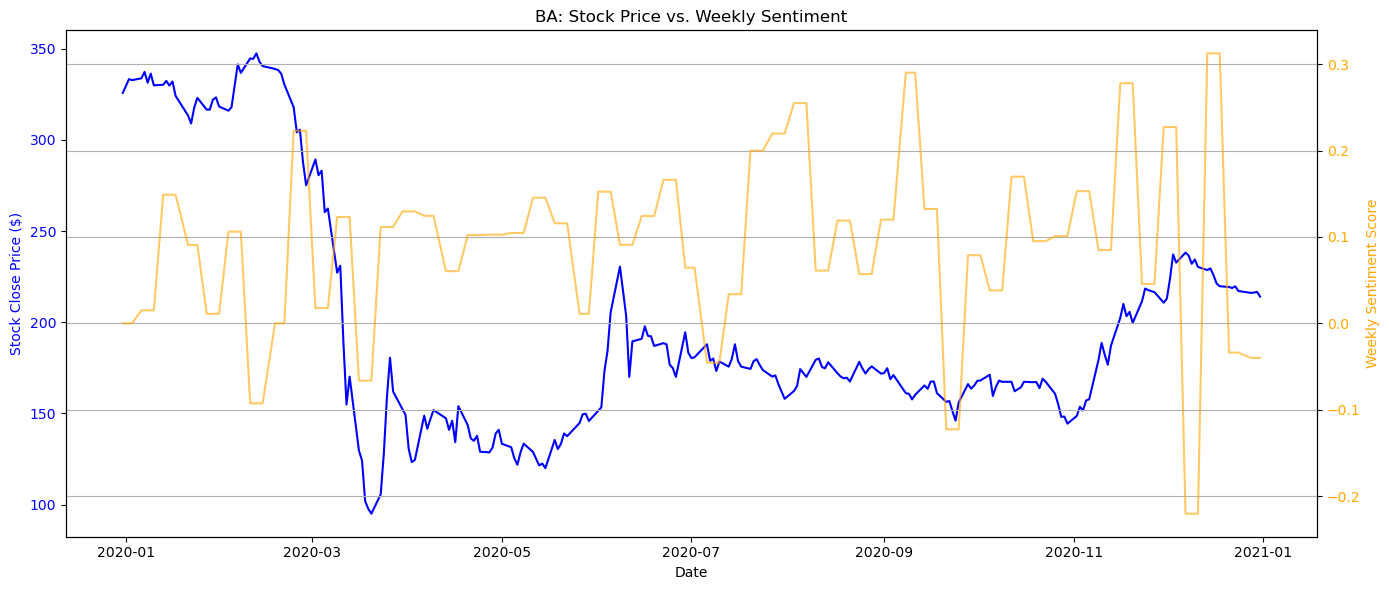

In [59]:
# choosing ticker... can swap out ticker later
selected_ticker = 'BA'
stock_data = df_merged[df_merged['ticker'] == selected_ticker].copy()
stock_data['date'] = pd.to_datetime(stock_data['date'])

# Plot
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(stock_data['date'], stock_data['close'], color='blue', label='Close Price')
ax1.set_ylabel('Stock Close Price ($)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(stock_data['date'], stock_data['weekly_sentiment'], color='orange', label='Weekly Sentiment', alpha=0.6)
ax2.set_ylabel('Weekly Sentiment Score', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title(f'{selected_ticker}: Stock Price vs. Weekly Sentiment')
fig.tight_layout()
plt.grid(True)
plt.show()

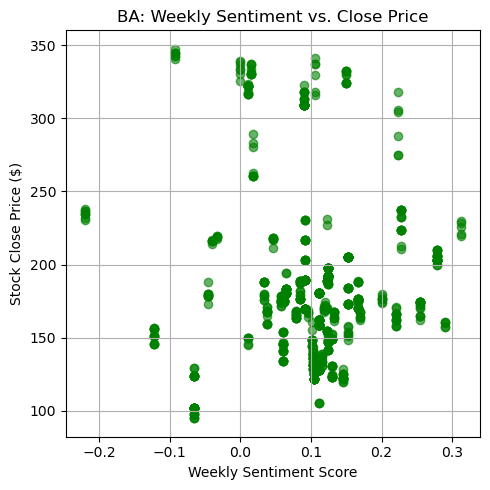

In [60]:
#Boeing 
#scatterplot with weekly sentiment
plt.figure(figsize=(5, 5))
plt.scatter(stock_data['weekly_sentiment'], stock_data['close'], alpha=0.6, color='green')
plt.title(f'{selected_ticker}: Weekly Sentiment vs. Close Price')
plt.xlabel('Weekly Sentiment Score')
plt.ylabel('Stock Close Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
r, p = pearsonr(stock_data['weekly_sentiment'], stock_data['close'])

print(f"Pearson correlation (r) between weekly sentiment and close price for {selected_ticker}: {r:.4f}")
print(f"P-value: {p:.4f}")

r_spearman, p_spearman = spearmanr(stock_data['weekly_sentiment'], stock_data['close'])
print(f"Spearman r = {r_spearman:.4f}, p-value = {p_spearman:.4f}")
# significant as sentiment increase, price tends to decrease slightly

Pearson correlation (r) between weekly sentiment and close price for BA: -0.0484
P-value: 0.1351
Spearman r = 0.0102, p-value = 0.7532


Doesn't seem to be any meaningful relationship between weekly sentiment and stock price for Boeing

### Choosing suitable companies
- looking first at use of granger causality test for using sentiment as a exogeneous variable
- the assumptions for this test are that the varaibles are stationary and alined by time, Need to use ADF here
- before using granger test I need to look at the ADF test for each of the 9 companies stock data to look for stationality there... doing this first

In [64]:
#ADF tests
#Ho: Time series is non-stationary
#Ha: Time series is stationary 
#for each ticker, if p is less than 0.05 the test was significant and we reject Ho.. thus stationary

# top 9 tickers list
top_9_list = ['TSLA', 'AAPL', 'BA', 'DIS', 'AMZN', 'MSFT', 'CCL', 'BABA', 'FB']

# storing results
adf_results = []

#looping through each ticker
for ticker in top_9_list:
    data = df_merged[df_merged['ticker'] == ticker].copy()
    data = data.sort_values('date')
     
    # dropping missing values and checking "close" exists
    if 'close' not in data.columns or data['close'].isnull().all():
        continue
    
    series = data['close'].dropna()
    # ADF test
    result = adfuller(series)
    
    adf_results.append({
        'Ticker': ticker,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    })

# converting to DataFrame
adf_df = pd.DataFrame(adf_results)
print(adf_df)

  Ticker  ADF Statistic   p-value Stationary
0   TSLA       0.384263  0.980897         No
1   AAPL      -0.805958  0.817366         No
2     BA      -2.957989  0.039008        Yes
3    DIS      -0.065232  0.952793         No
4   AMZN      -1.106280  0.712561         No
5   MSFT      -1.260772  0.646923         No
6    CCL      -3.946063  0.001721        Yes
7   BABA      -1.580625  0.493318         No
8     FB      -1.048747  0.735073         No


Can proceed with BA and CCL, but will need to apply differencing on others later.
Need to:
- look at sentiment values for these companies and ensure they are sationary
- check have sentiment data lining up with all the dates (forward fill/ back fill... using weekly scores where necessary (this can be done for the full dataset if necessary???)

In [66]:
#adding in daily sentiment to DataFrame, using forward fill, in case this has a better result for Granger Causality test... can use best suited value
# aggregating daily sentiment
daily_sentiment = df_merged.groupby(['ticker', 'date'])['sentiment'].mean().reset_index()#dealing with multiple tweets in a day
daily_sentiment.rename(columns={'sentiment': 'daily_sentiment'}, inplace=True)

# merging into main dataframe
df_merged = pd.merge(df_merged, daily_sentiment, on=['ticker', 'date'], how='left')

# forward-fill sentiment by ticker, using past values (no backfill to avoid data leakage)
df_merged.sort_values(['ticker', 'date'], inplace=True)
df_merged['daily_sentiment'] = df_merged.groupby('ticker')['daily_sentiment'].ffill()

In [67]:
print(df_merged.columns)

Index(['date', 'ticker', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'id', 'tweet', 'clean_tweet', 'sentiment', 'sentiment_label', 'week',
       'weekly_sentiment', 'daily_sentiment'],
      dtype='object')


In [68]:
#checking stationality of BA sentiment before trying Granger test
# filtering for BA
ba_data = df_merged[df_merged['ticker'] == 'BA'].copy()
ba_data = ba_data.sort_values('date')

# ADF test for daily sentiment
adf_daily = adfuller(ba_data['daily_sentiment'])
print("ADF Test on Daily Sentiment:")
print(f"ADF Statistic: {adf_daily[0]:.4f}")
print(f"p-value: {adf_daily[1]:.4f}")
print("Stationary?" , "Yes" if adf_daily[1] < 0.05 else "No")
print()

# ADF test for weekly sentiment
adf_weekly = adfuller(ba_data['weekly_sentiment'])
print("ADF Test on Weekly Sentiment:")
print(f"ADF Statistic: {adf_weekly[0]:.4f}")
print(f"p-value: {adf_weekly[1]:.4f}")
print("Stationary?" , "Yes" if adf_weekly[1] < 0.05 else "No")

ADF Test on Daily Sentiment:
ADF Statistic: -12.4500
p-value: 0.0000
Stationary? Yes

ADF Test on Weekly Sentiment:
ADF Statistic: -5.5233
p-value: 0.0000
Stationary? Yes


In [69]:
#Granger test for BA

# dataframes for input
gc_daily = ba_data[['close', 'daily_sentiment']]
gc_weekly = ba_data[['close', 'weekly_sentiment']]

# run Granger causality tests
print("Granger Causality Test: Daily Sentiment --> Close Price")
grangercausalitytests(gc_daily, maxlag=7, verbose=True)

print("\n Granger Causality Test: Weekly Sentiment --> Close Price")
grangercausalitytests(gc_weekly, maxlag=7, verbose=True)

Granger Causality Test: Daily Sentiment --> Close Price

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.2482  , p=0.2642  , df_denom=951, df_num=1
ssr based chi2 test:   chi2=1.2521  , p=0.2631  , df=1
likelihood ratio test: chi2=1.2513  , p=0.2633  , df=1
parameter F test:         F=1.2482  , p=0.2642  , df_denom=951, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.0634  , p=0.3457  , df_denom=948, df_num=2
ssr based chi2 test:   chi2=2.1380  , p=0.3434  , df=2
likelihood ratio test: chi2=2.1356  , p=0.3438  , df=2
parameter F test:         F=1.0634  , p=0.3457  , df_denom=948, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9408  , p=0.4203  , df_denom=945, df_num=3
ssr based chi2 test:   chi2=2.8432  , p=0.4164  , df=3
likelihood ratio test: chi2=2.8390  , p=0.4171  , df=3
parameter F test:         F=0.9408  , p=0.4203  , df_denom=945, df_num=3

Granger Causality
number of lags (no 

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{1: ({'ssr_ftest': (2.459324672134421, 0.11716165533988508, 951.0, 1),
   'ssr_chi2test': (2.467082794128536, 0.1162535103359581, 1),
   'lrtest': (2.4638982948954435, 0.11648935452503467, 1),
   'params_ftest': (2.459324672134725, 0.11716165533988268, 951.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.3284092493440967, 0.2653909512268743, 948.0, 2),
   'ssr_chi2test': (2.6708312544829624, 0.26304882247610356, 2),
   'lrtest': (2.667095661701751, 0.26354060324748096, 2),
   'params_ftest': (1.3284092493442756, 0.2653909512268266, 948.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.9266892971035797, 0.4272247906415687, 945.0, 3),
   'ssr_chi2test': (2.80066098680193, 0.42339111841751687, 3),
   'lrtest': (2.7965494571872114, 0.42406825288101724, 3),
   'params_ftest': (0.9266892971037004, 0.4272247906415162, 945.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0.,

Neither sentiment value showing much causality with Granger test, but could still prove useful with SARIMAX of LSTM if more complex relationship not showing up with this test.

In [71]:
#doing same for CCL
# filtering for CCL
ccl_data = df_merged[df_merged['ticker'] == 'CCL'].copy()
ccl_data = ccl_data.sort_values('date')

# ADF test for daily sentiment
adf_daily = adfuller(ccl_data['daily_sentiment'])
print("ADF Test on Daily Sentiment:")
print(f"ADF Statistic: {adf_daily[0]:.4f}")
print(f"p-value: {adf_daily[1]:.4f}")
print("Stationary?" , "Yes" if adf_daily[1] < 0.05 else "No")
print()

# ADF test for weekly sentiment
adf_weekly = adfuller(ccl_data['weekly_sentiment'])
print("ADF Test on Weekly Sentiment:")
print(f"ADF Statistic: {adf_weekly[0]:.4f}")
print(f"p-value: {adf_weekly[1]:.4f}")
print("Stationary?" , "Yes" if adf_weekly[1] < 0.05 else "No")

ADF Test on Daily Sentiment:
ADF Statistic: -9.7423
p-value: 0.0000
Stationary? Yes

ADF Test on Weekly Sentiment:
ADF Statistic: -5.8706
p-value: 0.0000
Stationary? Yes


In [72]:
#Granger test for CCL

# dataframes for input
gc_daily = ccl_data[['close', 'daily_sentiment']]
gc_weekly = ccl_data[['close', 'weekly_sentiment']]

# run Granger causality tests
print("Granger Causality Test: Daily Sentiment --> Close Price")
grangercausalitytests(gc_daily, maxlag=7, verbose=True)

print("\n Granger Causality Test: Weekly Sentiment --> Close Price")
grangercausalitytests(gc_weekly, maxlag=7, verbose=True)

Granger Causality Test: Daily Sentiment --> Close Price

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0006  , p=0.9804  , df_denom=399, df_num=1
ssr based chi2 test:   chi2=0.0006  , p=0.9803  , df=1
likelihood ratio test: chi2=0.0006  , p=0.9803  , df=1
parameter F test:         F=0.0006  , p=0.9804  , df_denom=399, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1547  , p=0.8567  , df_denom=396, df_num=2
ssr based chi2 test:   chi2=0.3133  , p=0.8550  , df=2
likelihood ratio test: chi2=0.3132  , p=0.8551  , df=2
parameter F test:         F=0.1547  , p=0.8567  , df_denom=396, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.1174  , p=0.9499  , df_denom=393, df_num=3
ssr based chi2 test:   chi2=0.3585  , p=0.9487  , df=3
likelihood ratio test: chi2=0.3584  , p=0.9487  , df=3
parameter F test:         F=0.1174  , p=0.9499  , df_denom=393, df_num=3

Granger Causality
number of lags (no 

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{1: ({'ssr_ftest': (1.1058812921662804, 0.2936154860741029, 399.0, 1),
   'ssr_chi2test': (1.1141961890998613, 0.2911716057549603, 1),
   'lrtest': (1.1126549651678488, 0.29150554539686735, 1),
   'params_ftest': (1.1058812921663317, 0.2936154860741094, 399.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.8507653951038573, 0.42786702034341506, 396.0, 2),
   'ssr_chi2test': (1.7230147648315495, 0.4225246957491826, 2),
   'lrtest': (1.7193236139180499, 0.4233052169914042, 2),
   'params_ftest': (0.8507653951038733, 0.42786702034340574, 396.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.8009403130023319, 0.4939049315454602, 393.0, 3),
   'ssr_chi2test': (2.4456192763429985, 0.485199105525015, 3),
   'lrtest': (2.4381732939368703, 0.48656823538070915, 3),
   'params_ftest': (0.8009403130022444, 0.4939049315455013, 393.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0

CCL also not showing strong Granger Test results. Moving on to differencing of other companies to see if they are a better choice for exogeneous variables use in forecasting.

Next Tickers I will try I will choose based on who has the most tweets in the file. First Tesal then, applie, DIS, amazon, and finally Microsoft.

In [74]:
def check_stationarity_with_diff(df, ticker):
    """
    For a given ticker, apply first-order differencing to the 'close' price only,
    and run ADF tests on:Differenced 'close' price, 'daily_sentiment' and  'weekly_sentiment' as they are.
    """
    #filtering and sort data
    data = df[df['ticker'] == ticker].copy()
    data = data.sort_values('date')

    # doing first-order differencing
    data['close_diff'] = data['close'].diff()
    
    # droppin nul values
    data = data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

    # ADF test helper
    def run_adf(series, label):
        result = adfuller(series)
        return {
            "Variable": label,
            "ADF Statistic": result[0],
            "p-value": result[1],
            "Stationary": "Yes" if result[1] < 0.05 else "No"
        }

    # running ADF for each series
    results = [
        run_adf(data['close_diff'], f'{ticker} - Close (diff)'),
        run_adf(data['daily_sentiment'], f'{ticker} - Daily Sentiment'),
        run_adf(data['weekly_sentiment'], f'{ticker} - Weekly Sentiment')
    ]

    return pd.DataFrame(results)

In [75]:
#using function to test Tesla first
check_stationarity_with_diff(df_merged, 'TSLA')

,Variable,ADF Statistic,p-value,Stationary
0,TSLA - Close (diff),-64.764199,0.000000e+00,Yes
1,TSLA - Daily Sentiment,-8.763217,2.639659e-14,Yes
2,TSLA - Weekly Sentiment,-6.212595,5.461791e-08,Yes


In [76]:
# will be able to do Granger test with TSLA next... but going to do ADF for other tickers first 
# then can do the granger tests altogether before chosing which companies to proceed with
#using function now to test Apple
check_stationarity_with_diff(df_merged, 'AAPL')

,Variable,ADF Statistic,p-value,Stationary
0,AAPL - Close (diff),-16.242012,3.719227e-29,Yes
1,AAPL - Daily Sentiment,-8.212894,6.743684e-13,Yes
2,AAPL - Weekly Sentiment,-5.076959,1.559428e-05,Yes


In [77]:
#now DIS
check_stationarity_with_diff(df_merged, 'DIS')

,Variable,ADF Statistic,p-value,Stationary
0,DIS - Close (diff),-24.217408,0.000000e+00,Yes
1,DIS - Daily Sentiment,-14.300604,1.230938e-26,Yes
2,DIS - Weekly Sentiment,-4.842026,4.516405e-05,Yes


In [78]:
#for Amazon
check_stationarity_with_diff(df_merged, 'AMZN')

,Variable,ADF Statistic,p-value,Stationary
0,AMZN - Close (diff),-22.169384,0.000000e+00,Yes
1,AMZN - Daily Sentiment,-8.759291,2.701482e-14,Yes
2,AMZN - Weekly Sentiment,-5.187000,9.345576e-06,Yes


In [79]:
#finally Microsoft
check_stationarity_with_diff(df_merged, 'MSFT')

,Variable,ADF Statistic,p-value,Stationary
0,MSFT - Close (diff),-6.387797,2.142710e-08,Yes
1,MSFT - Daily Sentiment,-8.073287,1.529071e-12,Yes
2,MSFT - Weekly Sentiment,-5.609802,1.210777e-06,Yes


In [80]:
#Tesla, Apple, Amazon, Disney and Microsoft all stationary after one difference
#Doing Granger tests next, starting with TESLA

# recreating the differenced TSLA dataset 
tsla_data = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla_data = tsla_data.sort_values('date')
tsla_data['close_diff'] = tsla_data['close'].diff()

# dropping missing values for Granger input
tsla_data = tsla_data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

# preparing input for Granger test [dependent, exogenous]
gc_daily = tsla_data[['close_diff', 'daily_sentiment']]
gc_weekly = tsla_data[['close_diff', 'weekly_sentiment']]

# running tests with max lag = 21... making higher to try find link.. but still no connection found
print("Granger Causality Test: Daily Sentiment --> Close (diff)")
grangercausalitytests(gc_daily, maxlag=21, verbose=True)

print("\nGranger Causality Test: Weekly Sentiment --> Close (diff)")
grangercausalitytests(gc_weekly, maxlag=21, verbose=True)

Granger Causality Test: Daily Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6195  , p=0.4313  , df_denom=4213, df_num=1
ssr based chi2 test:   chi2=0.6200  , p=0.4311  , df=1
likelihood ratio test: chi2=0.6199  , p=0.4311  , df=1
parameter F test:         F=0.6195  , p=0.4313  , df_denom=4213, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5060  , p=0.6029  , df_denom=4210, df_num=2
ssr based chi2 test:   chi2=1.0132  , p=0.6025  , df=2
likelihood ratio test: chi2=1.0131  , p=0.6026  , df=2
parameter F test:         F=0.5060  , p=0.6029  , df_denom=4210, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6431  , p=0.5872  , df_denom=4207, df_num=3
ssr based chi2 test:   chi2=1.9327  , p=0.5865  , df=3
likelihood ratio test: chi2=1.9322  , p=0.5866  , df=3
parameter F test:         F=0.6431  , p=0.5872  , df_denom=4207, df_num=3

Granger Causality
number of la

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


ssr based F test:         F=1.0055  , p=0.4425  , df_denom=4177, df_num=13
ssr based chi2 test:   chi2=13.1566 , p=0.4358  , df=13
likelihood ratio test: chi2=13.1361 , p=0.4374  , df=13
parameter F test:         F=1.0055  , p=0.4425  , df_denom=4177, df_num=13

Granger Causality
number of lags (no zero) 14
ssr based F test:         F=0.9348  , p=0.5198  , df_denom=4174, df_num=14
ssr based chi2 test:   chi2=13.1779 , p=0.5126  , df=14
likelihood ratio test: chi2=13.1573 , p=0.5142  , df=14
parameter F test:         F=0.9348  , p=0.5198  , df_denom=4174, df_num=14

Granger Causality
number of lags (no zero) 15
ssr based F test:         F=0.8873  , p=0.5784  , df_denom=4171, df_num=15
ssr based chi2 test:   chi2=13.4087 , p=0.5708  , df=15
likelihood ratio test: chi2=13.3873 , p=0.5724  , df=15
parameter F test:         F=0.8873  , p=0.5784  , df_denom=4171, df_num=15

Granger Causality
number of lags (no zero) 16
ssr based F test:         F=0.8970  , p=0.5725  , df_denom=4168, df_num=1

{1: ({'ssr_ftest': (0.023280585282122172, 0.8787369883288879, 4213.0, 1),
   'ssr_chi2test': (0.02329716295975008, 0.8786868464286408, 1),
   'lrtest': (0.023297098592593102, 0.8786870127179262, 1),
   'params_ftest': (0.023280585282259753, 0.8787369883288879, 4213.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.010320899631274432, 0.9897322031353667, 4210.0, 2),
   'ssr_chi2test': (0.020666314463573268, 0.9897200464257916, 2),
   'lrtest': (0.020666263801103923, 0.9897200714966227, 2),
   'params_ftest': (0.010320899632023279, 0.9897322031344415, 4210.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.4470542883615681, 0.7193953708949177, 4207.0, 3),
   'ssr_chi2test': (1.3433944172728651, 0.7188553330909863, 3),
   'lrtest': (1.3431803302919434, 0.7189059031712147, 3),
   'params_ftest': (0.4470542883618527, 0.719395370894697, 4207.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
   

All p-values greater than 0.05, so we fail to reject the null hypothesis that sentiment Granger-causes changes in Tesla's stock price.

In [82]:
#Now Apple
# recreating the differenced AAPL dataset 
apple_data = df_merged[df_merged['ticker'] == 'AAPL'].copy()
apple_data = apple_data.sort_values('date')
apple_data['close_diff'] = apple_data['close'].diff()

# dropping missing values for Granger input
apple_data = apple_data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

# preparing input for Granger test [dependent, exogenous]
gc_daily = apple_data[['close_diff', 'daily_sentiment']]
gc_weekly = apple_data[['close_diff', 'weekly_sentiment']]

# running tests with max lag = 14... higher that 7 but still no low enough p value
print("Granger Causality Test: Daily Sentiment --> Close (diff)")
grangercausalitytests(gc_daily, maxlag=14, verbose=True)

print("\nGranger Causality Test: Weekly Sentiment --> Close (diff)")
grangercausalitytests(gc_weekly, maxlag=14, verbose=True)

Granger Causality Test: Daily Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0273  , p=0.8689  , df_denom=1620, df_num=1
ssr based chi2 test:   chi2=0.0273  , p=0.8688  , df=1
likelihood ratio test: chi2=0.0273  , p=0.8688  , df=1
parameter F test:         F=0.0273  , p=0.8689  , df_denom=1620, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1629  , p=0.8497  , df_denom=1617, df_num=2
ssr based chi2 test:   chi2=0.3269  , p=0.8492  , df=2
likelihood ratio test: chi2=0.3268  , p=0.8492  , df=2
parameter F test:         F=0.1629  , p=0.8497  , df_denom=1617, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4297  , p=0.2323  , df_denom=1614, df_num=3
ssr based chi2 test:   chi2=4.3077  , p=0.2301  , df=3
likelihood ratio test: chi2=4.3020  , p=0.2306  , df=3
parameter F test:         F=1.4297  , p=0.2323  , df_denom=1614, df_num=3

Granger Causality
number of la

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


likelihood ratio test: chi2=5.1058  , p=0.8840  , df=10
parameter F test:         F=0.5047  , p=0.8877  , df_denom=1593, df_num=10

Granger Causality
number of lags (no zero) 11
ssr based F test:         F=0.4984  , p=0.9052  , df_denom=1590, df_num=11
ssr based chi2 test:   chi2=5.5620  , p=0.9009  , df=11
likelihood ratio test: chi2=5.5524  , p=0.9015  , df=11
parameter F test:         F=0.4984  , p=0.9052  , df_denom=1590, df_num=11

Granger Causality
number of lags (no zero) 12
ssr based F test:         F=0.4589  , p=0.9385  , df_denom=1587, df_num=12
ssr based chi2 test:   chi2=5.5939  , p=0.9352  , df=12
likelihood ratio test: chi2=5.5842  , p=0.9356  , df=12
parameter F test:         F=0.4589  , p=0.9385  , df_denom=1587, df_num=12

Granger Causality
number of lags (no zero) 13
ssr based F test:         F=0.4263  , p=0.9610  , df_denom=1584, df_num=13
ssr based chi2 test:   chi2=5.6361  , p=0.9584  , df=13
likelihood ratio test: chi2=5.6262  , p=0.9587  , df=13
parameter F test:

{1: ({'ssr_ftest': (0.1650446621293073, 0.6846075136325784, 1620.0, 1),
   'ssr_chi2test': (0.16535030039250972, 0.6842776431680507, 1),
   'lrtest': (0.16534187806792033, 0.6842852506447321, 1),
   'params_ftest': (0.16504466212950097, 0.6846075136324157, 1620.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.0870916148452909, 0.9165974174640009, 1617.0, 2),
   'ssr_chi2test': (0.1747218296587036, 0.9163463129713857, 2),
   'lrtest': (0.1747124198172969, 0.9163506243182674, 2),
   'params_ftest': (0.08709161484515371, 0.9165974174640832, 1617.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.906631415224493, 0.4371015848404596, 1614.0, 3),
   'ssr_chi2test': (2.731690565202422, 0.4348686512344506, 3),
   'lrtest': (2.7293914410420257, 0.43525561241593236, 3),
   'params_ftest': (0.9066314152244409, 0.43710158484048955, 1614.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0.

All p-values greater than 0.05, so we fail to reject the null hypothesis that sentiment Granger-causes changes in Apple's stock price.

In [84]:
#Disney 
dis_data = df_merged[df_merged['ticker'] == 'DIS'].copy()
dis_data = dis_data.sort_values('date')
dis_data['close_diff'] = dis_data['close'].diff()

# dropping missing values for Granger input
dis_data = dis_data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

# preparing input for Granger test [dependent, exogenous]
gc_daily = dis_data[['close_diff', 'daily_sentiment']]
gc_weekly = dis_data[['close_diff', 'weekly_sentiment']]

# running tests with max lag = 7
print("Granger Causality Test: Daily Sentiment --> Close (diff)")
grangercausalitytests(gc_daily, maxlag=7, verbose=True)

print("\nGranger Causality Test: Weekly Sentiment --> Close (diff)")
grangercausalitytests(gc_weekly, maxlag=7, verbose=True)

Granger Causality Test: Daily Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6684  , p=0.4140  , df_denom=542, df_num=1
ssr based chi2 test:   chi2=0.6721  , p=0.4123  , df=1
likelihood ratio test: chi2=0.6717  , p=0.4125  , df=1
parameter F test:         F=0.6684  , p=0.4140  , df_denom=542, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3037  , p=0.7382  , df_denom=539, df_num=2
ssr based chi2 test:   chi2=0.6131  , p=0.7360  , df=2
likelihood ratio test: chi2=0.6127  , p=0.7361  , df=2
parameter F test:         F=0.3037  , p=0.7382  , df_denom=539, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.3603  , p=0.2541  , df_denom=536, df_num=3
ssr based chi2 test:   chi2=4.1343  , p=0.2473  , df=3
likelihood ratio test: chi2=4.1186  , p=0.2489  , df=3
parameter F test:         F=1.3603  , p=0.2541  , df_denom=536, df_num=3

Granger Causality
number of lags (no

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{1: ({'ssr_ftest': (0.11448657961859168, 0.7352239544270951, 542.0, 1),
   'ssr_chi2test': (0.11512026917367614, 0.7343884278586059, 1),
   'lrtest': (0.11510811246671437, 0.7344019226088954, 1),
   'params_ftest': (0.11448657961849677, 0.7352239544271622, 542.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.4454394144882325, 0.23655442381871022, 539.0, 2),
   'ssr_chi2test': (2.9176958867591782, 0.2325039782427543, 2),
   'lrtest': (2.9098993497741503, 0.23341211009638319, 2),
   'params_ftest': (1.4454394144882565, 0.23655442381871022, 539.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.996916222640105, 0.3939104431781384, 536.0, 3),
   'ssr_chi2test': (3.029806952762558, 0.3870523227455439, 3),
   'lrtest': (3.021385474550243, 0.38833969481608327, 3),
   'params_ftest': (0.9969162226401198, 0.3939104431781384, 536.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0.,

Result: All p-values greater than 0.05, so we fail to reject the null hypothesis that sentiment Granger-causes changes in Disney's stock price.

In [86]:
#Amazon 
amazon_data = df_merged[df_merged['ticker'] == 'AMZN'].copy()
amazon_data = amazon_data.sort_values('date')
amazon_data['close_diff'] = amazon_data['close'].diff()

# dropping missing values for Granger input
amazon_data = amazon_data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

# preparing input for Granger test [dependent, exogenous]
gc_daily = amazon_data[['close_diff', 'daily_sentiment']]
gc_weekly = amazon_data[['close_diff', 'weekly_sentiment']]

# running tests with max lag = 7
print("Granger Causality Test: Daily Sentiment --> Close (diff)")
grangercausalitytests(gc_daily, maxlag=7, verbose=True)

print("\nGranger Causality Test: Weekly Sentiment --> Close (diff)")
grangercausalitytests(gc_weekly, maxlag=7, verbose=True)

Granger Causality Test: Daily Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


ssr based F test:         F=1.1201  , p=0.2904  , df_denom=479, df_num=1
ssr based chi2 test:   chi2=1.1272  , p=0.2884  , df=1
likelihood ratio test: chi2=1.1258  , p=0.2887  , df=1
parameter F test:         F=1.1201  , p=0.2904  , df_denom=479, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.1616  , p=0.3139  , df_denom=476, df_num=2
ssr based chi2 test:   chi2=2.3475  , p=0.3092  , df=2
likelihood ratio test: chi2=2.3418  , p=0.3101  , df=2
parameter F test:         F=1.1616  , p=0.3139  , df_denom=476, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7353  , p=0.5313  , df_denom=473, df_num=3
ssr based chi2 test:   chi2=2.2386  , p=0.5244  , df=3
likelihood ratio test: chi2=2.2334  , p=0.5254  , df=3
parameter F test:         F=0.7353  , p=0.5313  , df_denom=473, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.6219  , p=0.6471  , df_denom=470, df_num=4
ssr based chi2 test: 

{1: ({'ssr_ftest': (1.4120904996587575, 0.23529850355723073, 479.0, 1),
   'ssr_chi2test': (1.4209344902620484, 0.23324965180630336, 1),
   'lrtest': (1.4188441422670621, 0.2335937452849658, 1),
   'params_ftest': (1.4120904996586652, 0.2352985035572342, 479.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (2.620666030043951, 0.07380397128984158, 476.0, 2),
   'ssr_chi2test': (5.296388069122439, 0.07077892199367411, 2),
   'lrtest': (5.267440574139073, 0.07181080785199087, 2),
   'params_ftest': (2.6206660300439797, 0.07380397128983973, 476.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (2.1231964455323564, 0.09645436303383609, 473.0, 3),
   'ssr_chi2test': (6.463853872233812, 0.09109896984211358, 3),
   'lrtest': (6.420718393904281, 0.09284216347660648, 3),
   'params_ftest': (2.123196445532369, 0.09645436303383188, 473.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 

Result: still all above 0.05 but marginal signal at lag 6 for weekly sentiment with a p-value of 0.0543 at lag 6. While this is slightly above the 0.05 threshold for statistical significance could still be useful as exogeneous variable in model.. especially considering the short time series and limited tweet data available.

In [88]:
#Microsoft
# recreating the differenced MSFT dataset 
msft_data = df_merged[df_merged['ticker'] == 'MSFT'].copy()
msft_data = msft_data.sort_values('date')
msft_data['close_diff'] = msft_data['close'].diff()

# dropping missing values for Granger input
msft_data = msft_data.dropna(subset=['close_diff', 'daily_sentiment', 'weekly_sentiment'])

# preparing input for Granger test [dependent, exogenous]
gc_daily = msft_data[['close_diff', 'daily_sentiment']]
gc_weekly = msft_data[['close_diff', 'weekly_sentiment']]

# running tests with max lag = 14 ... made higher to try find link
print("Granger Causality Test: Daily Sentiment --> Close (diff)")
grangercausalitytests(gc_daily, maxlag=14, verbose=True)

print("\nGranger Causality Test: Weekly Sentiment --> Close (diff)")
grangercausalitytests(gc_weekly, maxlag=14, verbose=True)

Granger Causality Test: Daily Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4781  , p=0.4897  , df_denom=384, df_num=1
ssr based chi2 test:   chi2=0.4818  , p=0.4876  , df=1
likelihood ratio test: chi2=0.4815  , p=0.4877  , df=1
parameter F test:         F=0.4781  , p=0.4897  , df_denom=384, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5291  , p=0.5896  , df_denom=381, df_num=2
ssr based chi2 test:   chi2=1.0721  , p=0.5851  , df=2
likelihood ratio test: chi2=1.0706  , p=0.5855  , df=2
parameter F test:         F=0.5291  , p=0.5896  , df_denom=381, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.6293  , p=0.5964  , df_denom=378, df_num=3
ssr based chi2 test:   chi2=1.9230  , p=0.5885  , df=3
likelihood ratio test: chi2=1.9182  , p=0.5896  , df=3
parameter F test:         F=0.6293  , p=0.5964  , df_denom=378, df_num=3

Granger Causality
number of lags (no

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(



parameter F test:         F=1.2979  , p=0.2061  , df_denom=345, df_num=14

Granger Causality Test: Weekly Sentiment --> Close (diff)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.8639  , p=0.3532  , df_denom=384, df_num=1
ssr based chi2 test:   chi2=0.8707  , p=0.3508  , df=1
likelihood ratio test: chi2=0.8697  , p=0.3510  , df=1
parameter F test:         F=0.8639  , p=0.3532  , df_denom=384, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.5821  , p=0.5592  , df_denom=381, df_num=2
ssr based chi2 test:   chi2=1.1795  , p=0.5545  , df=2
likelihood ratio test: chi2=1.1777  , p=0.5550  , df=2
parameter F test:         F=0.5821  , p=0.5592  , df_denom=381, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.4329  , p=0.7296  , df_denom=378, df_num=3
ssr based chi2 test:   chi2=1.3227  , p=0.7238  , df=3
likelihood ratio test: chi2=1.3204  , p=0.7243  , df=3
parameter F test:         F=0.432

{1: ({'ssr_ftest': (0.8639352098129405, 0.3532237055210986, 384.0, 1),
   'ssr_chi2test': (0.870684703639604, 0.35076582347294794, 1),
   'lrtest': (0.869706723386571, 0.35103651278908843, 1),
   'params_ftest': (0.8639352098129743, 0.3532237055210986, 384.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.5821142066359019, 0.5592120017210618, 381.0, 2),
   'ssr_chi2test': (1.1795070013724835, 0.5544639428721683, 2),
   'lrtest': (1.1777085439957773, 0.5549627569966294, 2),
   'params_ftest': (0.5821142066359293, 0.5592120017210496, 381.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.4328715307643027, 0.7295839615343391, 378.0, 3),
   'ssr_chi2test': (1.3226630106687027, 0.7237586844337347, 3),
   'lrtest': (1.3203962042348394, 0.724295588159687, 3),
   'params_ftest': (0.4328715307643043, 0.7295839615343391, 378.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0

All p-values greater than 0.05, so we fail to reject the null hypothesis that sentiment Granger-causes changes in Microsoft's stock price. but weak evidence at lag 9 for daily sentiment after I increased the lags: p=0.0874

## Forecasting
- Starting with companies that showed some correlation with exogeneous tweet sentiment data
- Testing for Seasonality to decide whether SARIMAX or ARIMAX is the best way forward
Starting with Amazon... lag 6 weekly
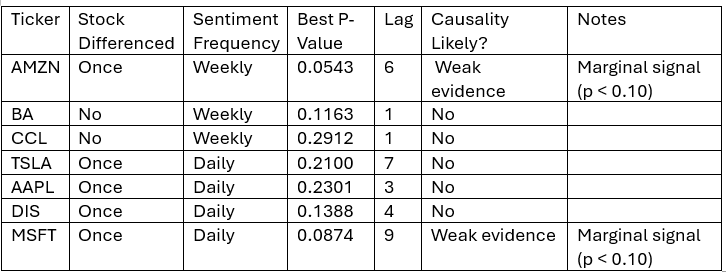

In [91]:
#loading and preparing the data

#getting AMZN data
amzn_df = df_merged[df_merged['ticker'] == 'AMZN'].copy()

#getting dates to correct format, date as index
amzn_df['date'] = pd.to_datetime(amzn_df['date'])
amzn_df.set_index('date', inplace=True)

# Lag the sentiment (as Granger test suggested... lag=6)
amzn_df['sentiment_lag6'] = amzn_df['weekly_sentiment'].shift(6)

#keeping necessary columns only (close and laggd weekly sentiment)
merged = amzn_df[['close', 'sentiment_lag6']].copy()
merged['sentiment_lag6'] = merged['sentiment_lag6'].fillna(0)  # Fill missing values

#checking ok
print(merged.head(10))

                close  sentiment_lag6
date                                 
2019-12-31  92.391998         0.00000
2020-01-02  94.900497         0.00000
2020-01-03  93.748497         0.00000
2020-01-06  95.143997         0.00000
2020-01-07  95.343002         0.00000
2020-01-08  94.598503         0.00000
2020-01-09  95.052498         0.00000
2020-01-10  94.157997         0.00000
2020-01-13  94.565002         0.00000
2020-01-14  93.472000         0.25652


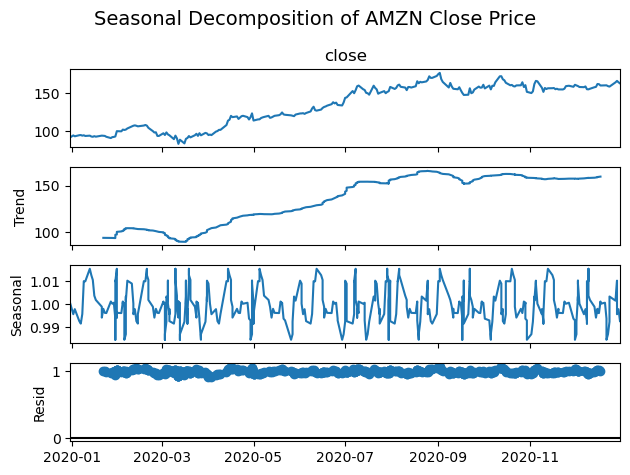

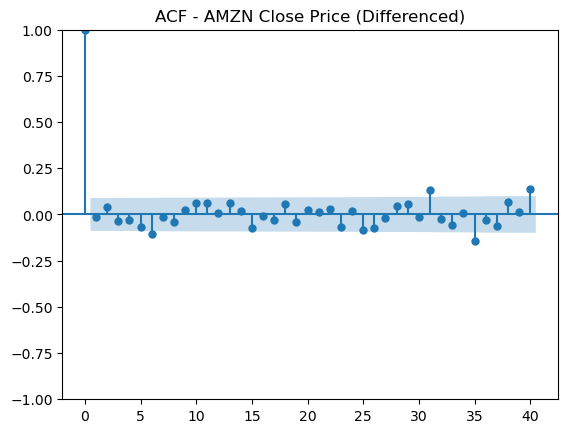

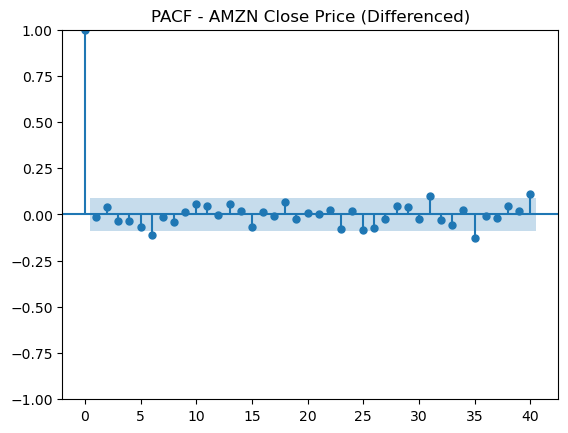

In [92]:
# decompsing close price... plot doesn't look too seasonal but we will test monthly seasonality here (30 days)
decomposition = seasonal_decompose(merged['close'], model='multiplicative', period=30)
decomposition.plot()
plt.suptitle('Seasonal Decomposition of AMZN Close Price', fontsize=14)
plt.tight_layout()
plt.show()

# doing differencing once to ensure using stationary data for ACF and PACF
close_diff = merged['close'].diff().dropna()

#getting ACF and PACF plots to understand autocorrelation
plot_acf(close_diff, lags=40) #ACF
plt.title('ACF - AMZN Close Price (Differenced)')
plt.show()

# PACF
plot_pacf(close_diff, lags=40)
plt.title('PACF - AMZN Close Price (Differenced)')
plt.show()

Trend is steadily increasing, doesn't seem to be much seasonality, no clear monthly repeating cycles... just some small fluctuations. Residuals are stable with not much seasonal impact... ARIMAX makes more sense here than Sarimax.

both ACF and PACF have a big drop after the first, so using q=1 (AR) and p=1 ...d will be one as data was differenced once to get stationality

In [94]:
#splitting the data ready for traon/test/split
#using last two months for test
train = merged[merged.index < '2020-11-01']
test = merged[merged.index >= '2020-11-01']

#ensuring alignment
train_close = train['close']
train_exog = train[['sentiment_lag6']]

test_close = test['close']
test_exog = test[['sentiment_lag6']]

In [95]:
#using ARIMAX as no seasonality apparent
model = SARIMAX(train_close,
                exog=train_exog,
                order=(1, 1, 1), #using 1,1,1 - see markdown above
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  414
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -926.635
Date:                Wed, 14 May 2025   AIC                           1861.270
Time:                        20:52:43   BIC                           1877.345
Sample:                             0   HQIC                          1867.629
                                - 414                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sentiment_lag6     0.1661      4.015      0.041      0.967      -7.704       8.036
ar.L1             -0.3981      1.715     -0.232      0.816      -3.760       2.964
ma.L1              0.3778      1.736

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Doesn't look like exogeneous variable is contributing much... which is consistent with Granger test... will run as ARIMAX anyway and compare accuracy with ARIMA


Forecast (1-day ahead):
date
2020-11-02    151.738434
dtype: float64


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


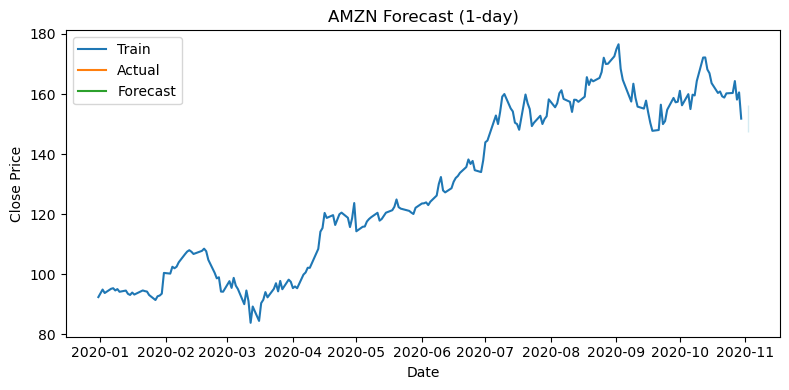

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (3-day ahead):
date
2020-11-02    151.738434
2020-11-03    151.765926
2020-11-04    151.754982
Name: predicted_mean, dtype: float64


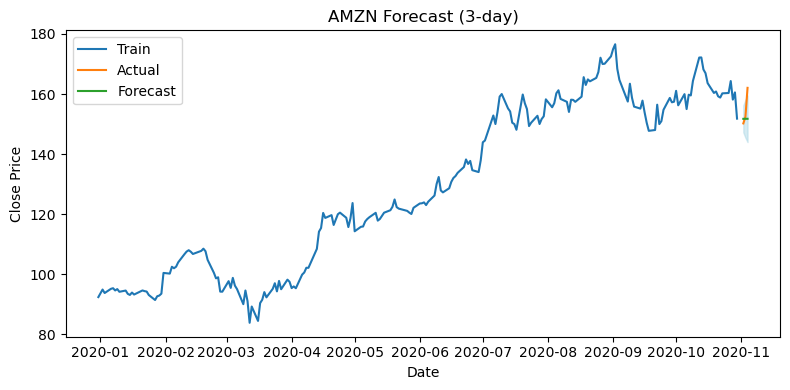

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (7-day ahead):
date
2020-11-02    151.738434
2020-11-03    151.765926
2020-11-04    151.754982
2020-11-04    151.759338
2020-11-05    151.757604
2020-11-05    151.758295
2020-11-06    151.764958
Name: predicted_mean, dtype: float64


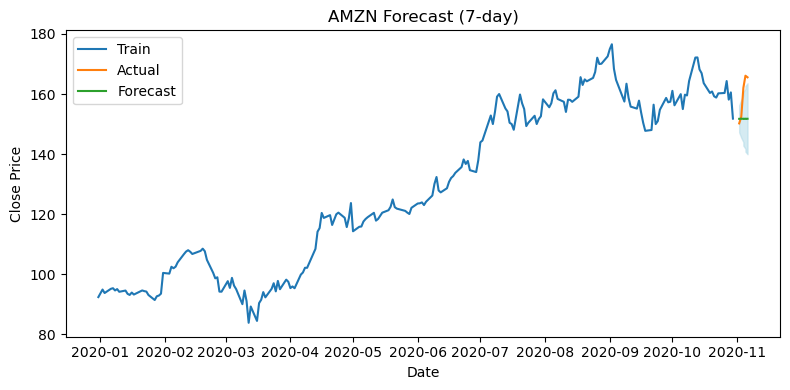

In [97]:
# Doing forcasting for 1, 3 and 7 days ahead
forecast_steps = [1, 3, 7]

# making sure date is in right and as index
train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)

#Function to loop for forecast lengths to forecast and display
for step in forecast_steps:
    #getting the forecast
    pred = results.get_forecast(steps=step, exog=test_exog[:step])
    pred_mean = pred.predicted_mean
    conf_int = pred.conf_int()
    
   # fixing datetime index agin due to odd plots
    if not isinstance(pred_mean.index, pd.DatetimeIndex):
        pred_mean.index = test.index[:step]
        conf_int.index = test.index[:step]
    
    #printing the predicted values
    print(f"\nForecast ({step}-day ahead):")
    print(pred_mean)

    # plot
    plt.figure(figsize=(8, 4))
    plt.plot(train.index, train_close, label='Train')
    plt.plot(test.index[:step], test_close[:step], label='Actual')
    plt.plot(pred_mean.index, pred_mean, label='Forecast')
    plt.fill_between(conf_int.index,
                     conf_int.iloc[:, 0],
                     conf_int.iloc[:, 1], color='lightblue', alpha=0.5)
    plt.title(f'AMZN Forecast ({step}-day)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [98]:
#evaluating accuracy with RMSE
print("\nRMSE Scores:")
for step in forecast_steps:
    pred = results.get_forecast(steps=step, exog=test_exog[:step])
    pred_mean = pred.predicted_mean
    actual = test_close[:step]

    rmse = np.sqrt(mean_squared_error(actual, pred_mean))
    print(f"{step}-day RMSE: {rmse:.2f}")

    df_preds = pd.DataFrame({
        'forecast_made_on': [test.index[0]] * step,
        'day_ahead': list(range(1, step + 1)),
        'forecast': pred_mean.values,
        'actual': actual.values
    })

    save_arima_forecast_with_stock(df_preds, 'AMZN', 'arimax', step)


RMSE Scores:
1-day RMSE: 1.51
Saved full timeline with forecast: forecast_exports/AMZN_arimax_1d_full.csv
3-day RMSE: 6.02
Saved full timeline with forecast: forecast_exports/AMZN_arimax_3d_full.csv
7-day RMSE: 10.80
Saved full timeline with forecast: forecast_exports/AMZN_arimax_7d_full.csv


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

Better accurcy for shorted predictons which is to be expected with time series forcasting... checking now to see if accuracy is better if the sentiment data is excluded.

In [138]:
# logging RMSE scores for dashboard
rmse_amzn_arimax = [
    {'ticker': 'AMZN', 'model': 'arimax', 'horizon': 1, 'rmse': 1.51},
    {'ticker': 'AMZN', 'model': 'arimax', 'horizon': 3, 'rmse': 6.02},
    {'ticker': 'AMZN', 'model': 'arimax', 'horizon': 7, 'rmse': 10.80}
]

df_rmse = pd.DataFrame(rmse_amzn_arimax)
df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)

In [140]:
# also saving Amazon weekly sentiment trend
sentiment_trend_amzn = df_merged[df_merged['ticker'] == 'AMZN'][['date', 'weekly_sentiment']]
sentiment_trend_amzn = sentiment_trend_amzn.groupby('date').mean().reset_index()
sentiment_trend_amzn.to_csv("forecast_exports/AMZN_sentiment_trend.csv", index=False)

In [142]:
# fit ARIMA without exogenous variables
arima_model = SARIMAX(train_close,
                      order=(1, 1, 1),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

arima_results = arima_model.fit(disp=False)
print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  414
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -926.639
Date:                Wed, 14 May 2025   AIC                           1859.279
Time:                        21:15:03   BIC                           1871.335
Sample:                             0   HQIC                          1864.048
                                - 414                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3973      1.715     -0.232      0.817      -3.759       2.965
ma.L1          0.3770      1.736      0.217      0.828      -3.025       3.779
sigma2         5.3189      0.206     25.802      0.0

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


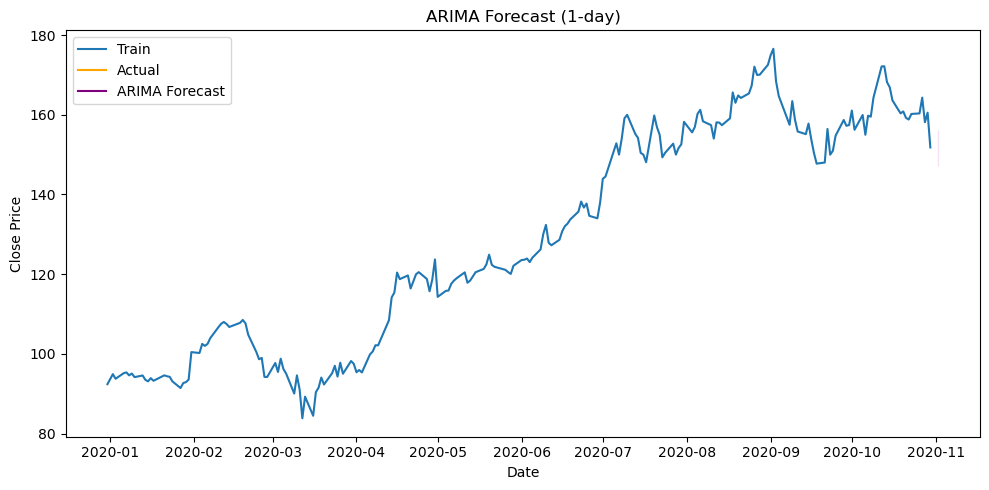

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


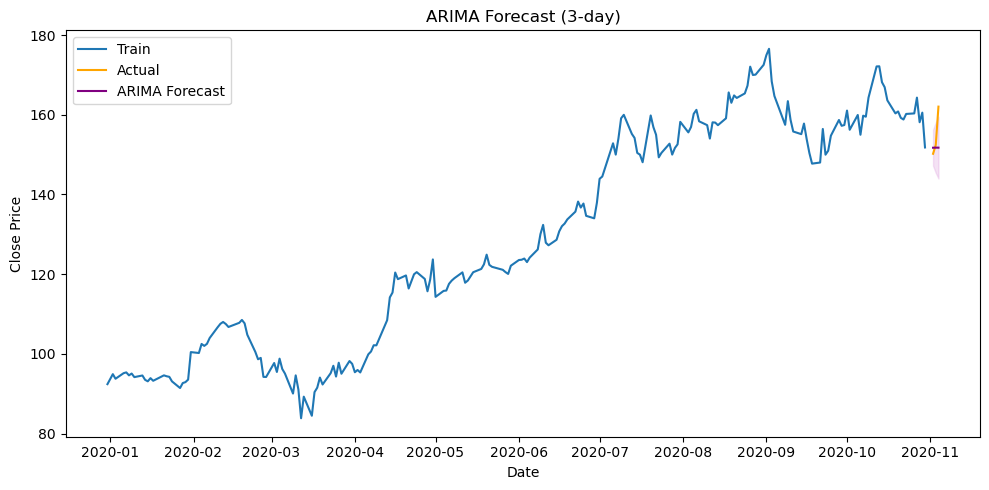

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


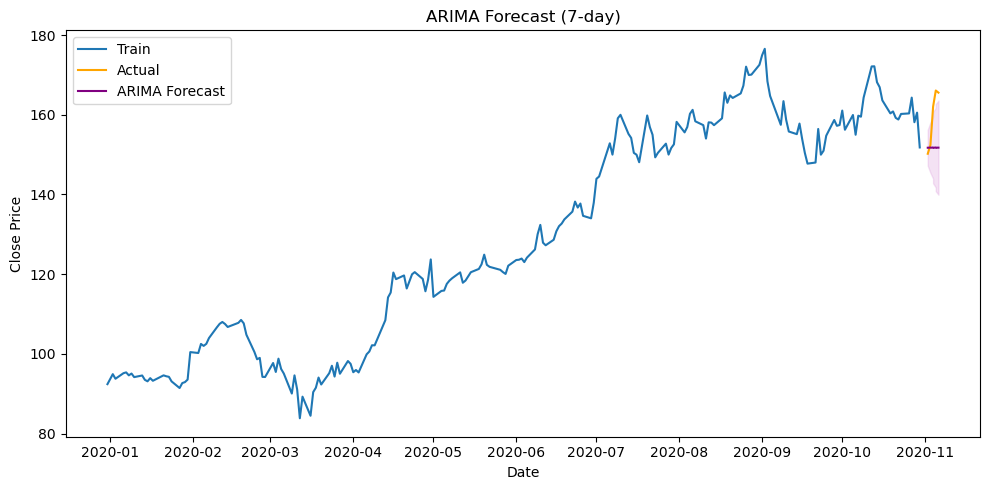

In [144]:
#plotting forcasts
for step in forecast_steps:
    arima_pred = arima_results.get_forecast(steps=step)
    arima_mean = arima_pred.predicted_mean
    arima_conf = arima_pred.conf_int()

    # fixing index again 
    if not isinstance(arima_mean.index, pd.DatetimeIndex):
        arima_mean.index = test.index[:step]
        arima_conf.index = test.index[:step]

    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train_close, label='Train')
    plt.plot(test.index[:step], test_close[:step], label='Actual', color='orange')
    plt.plot(arima_mean.index, arima_mean, label='ARIMA Forecast', color='purple')
    plt.fill_between(arima_conf.index,
                     arima_conf.iloc[:, 0],
                     arima_conf.iloc[:, 1],
                     color='plum', alpha=0.3)
    plt.title(f'ARIMA Forecast ({step}-day)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [145]:
#Getting RMSE for just ARIMA
print("\nARIMA RMSE Scores:")
for step in forecast_steps:
    arima_pred = arima_results.get_forecast(steps=step)
    arima_mean = arima_pred.predicted_mean
    actual = test_close[:step]

    rmse = np.sqrt(mean_squared_error(actual, arima_mean))
    print(f"{step}-day RMSE: {rmse:.2f}")

    df_preds = pd.DataFrame({
        'forecast_made_on': [test.index[0]] * step,
        'day_ahead': list(range(1, step + 1)),
        'forecast': arima_mean.values,
        'actual': actual.values
    })

    save_arima_forecast_with_stock(df_preds, 'AMZN', 'arima', step)


ARIMA RMSE Scores:
1-day RMSE: 1.51
Saved full timeline with forecast: forecast_exports/AMZN_arima_1d_full.csv
3-day RMSE: 6.02
Saved full timeline with forecast: forecast_exports/AMZN_arima_3d_full.csv
7-day RMSE: 10.80
Saved full timeline with forecast: forecast_exports/AMZN_arima_7d_full.csv


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

In [146]:
#Adding RMSE to table 
new_rmse_rows = [
    {'ticker': 'AMZN', 'model': 'arima', 'horizon': 1, 'rmse': 1.51},
    {'ticker': 'AMZN', 'model': 'arima', 'horizon': 3, 'rmse': 6.02},
    {'ticker': 'AMZN', 'model': 'arima', 'horizon': 7, 'rmse': 10.80}
]

df_rmse = pd.concat([df_rmse, pd.DataFrame(new_rmse_rows)], ignore_index=True)
df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)
print("Updated RMSE summary with ARIMA")

Updated RMSE summary with ARIMA


RMSE values identical for both with suggests exogeneous variables did not provide any useful information. The AIC score favored ARIMA. This suggests that sentiment did not contribute meaningfully to short-term price prediction for AMZN during the test period.

### Microsoft next
- following same procedure as Amazon
- this is the only other company I looked at that had at least a weak p value <0.1

In [152]:
#loading and preparing the data

#getting Microfost data
msft_df = df_merged[df_merged['ticker'] == 'MSFT'].copy()

#getting dates to correct format, date as index
msft_df['date'] = pd.to_datetime(msft_df['date'])
msft_df.set_index('date', inplace=True)

# Lag the sentiment (as Granger test suggested... lag=9)
msft_df['sentiment_lag6'] = msft_df['daily_sentiment'].shift(9) #daily this time

#keeping necessary columns only (close and laggd weekly sentiment)
merged = msft_df[['close', 'sentiment_lag6']].copy()
merged['sentiment_lag6'] = merged['sentiment_lag6'].fillna(0)  # Fill missing values

#checking ok
print(merged.tail(10))

                 close  sentiment_lag6
date                                  
2020-12-18  218.589996          0.0000
2020-12-21  222.589996          0.0000
2020-12-22  223.940002          0.0000
2020-12-23  221.020004          0.0000
2020-12-23  221.020004          0.8625
2020-12-24  222.750000          0.0000
2020-12-28  224.960007          0.4215
2020-12-29  224.149994          0.0000
2020-12-30  221.679993          0.0000
2020-12-31  222.419998          0.0000


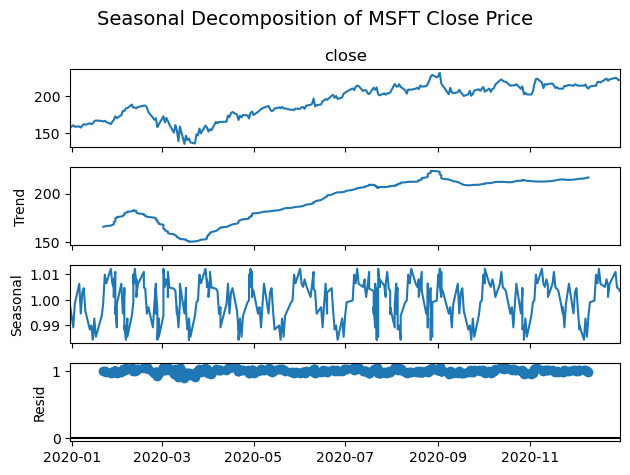

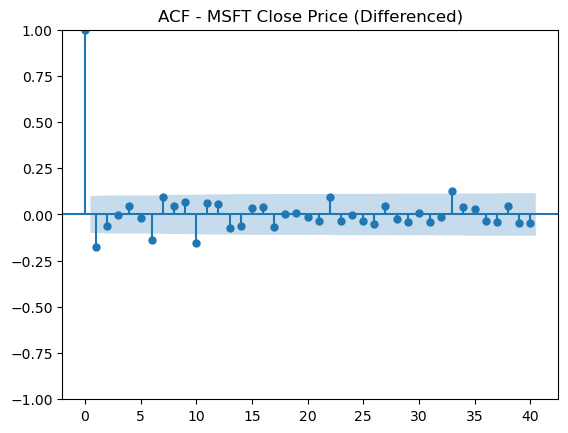

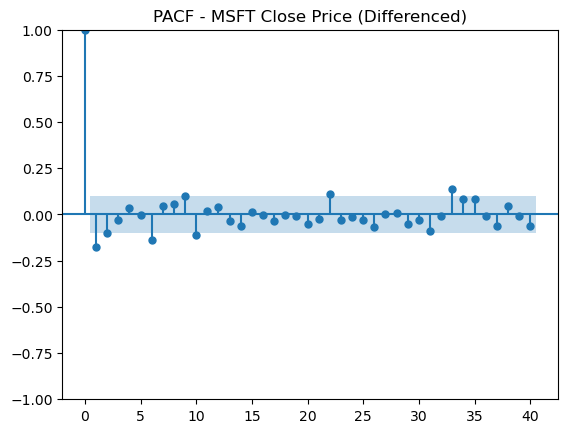

In [153]:
#alot of missing tweet data here... lots of zro sentiment...not expecting big impact for exo
decomposition = seasonal_decompose(merged['close'], model='multiplicative', period=30)
decomposition.plot()
plt.suptitle('Seasonal Decomposition of MSFT Close Price', fontsize=14)
plt.tight_layout()
plt.show()

# doing differencing once to ensure using stationary data for ACF and PACF
close_diff = merged['close'].diff().dropna()

#getting ACF and PACF plots to understand autocorrelation
plot_acf(close_diff, lags=40) #ACF
plt.title('ACF - MSFT Close Price (Differenced)')
plt.show()

# PACF
plot_pacf(close_diff, lags=40)
plt.title('PACF - MSFT Close Price (Differenced)')
plt.show()

Some clutering but not obvious seasonality again... going to use ARIMAX again and use (1,1,1)- same reason as AMzon

In [156]:
#splitting the data ready for traon/test/split
#using last two months for test
train = merged[merged.index < '2020-11-01']
test = merged[merged.index >= '2020-11-01']

#ensuring alignment
train_close = train['close']
train_exog = train[['sentiment_lag6']]

test_close = test['close']
test_exog = test[['sentiment_lag6']]

In [157]:
#using ARIMAX as no seasonality apparent
model = SARIMAX(train_close,
                exog=train_exog,
                order=(1, 1, 1), #using 1,1,1 - see markdown above
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  343
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -938.469
Date:                Wed, 14 May 2025   AIC                           1884.938
Time:                        21:15:07   BIC                           1900.254
Sample:                             0   HQIC                          1891.040
                                - 343                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sentiment_lag6    -2.2428      0.984     -2.278      0.023      -4.172      -0.313
ar.L1              0.1377      0.220      0.627      0.531      -0.293       0.568
ma.L1             -0.3640      0.206

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (1-day ahead):
date
2020-11-02    202.926279
dtype: float64


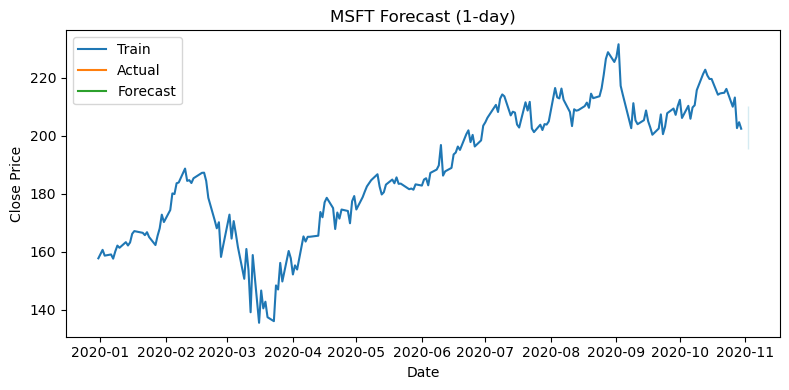

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (3-day ahead):
date
2020-11-02    202.926279
2020-11-03    202.611268
2020-11-04    202.619922
Name: predicted_mean, dtype: float64


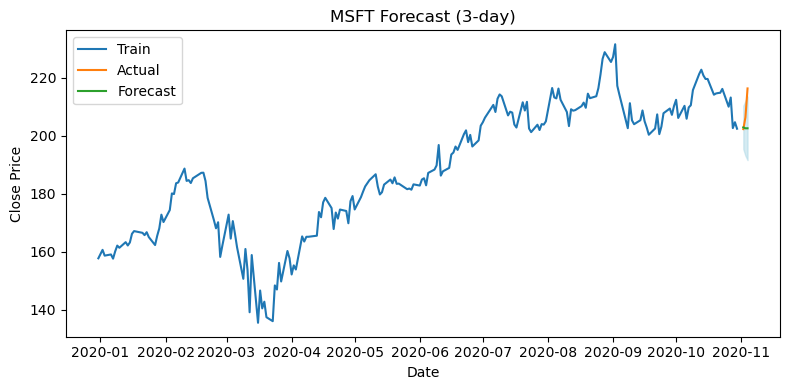

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (7-day ahead):
date
2020-11-02    202.926279
2020-11-03    202.611268
2020-11-04    202.619922
2020-11-05    202.621114
2020-11-06    202.621278
2020-11-09    202.071657
2020-11-10    202.071660
Name: predicted_mean, dtype: float64


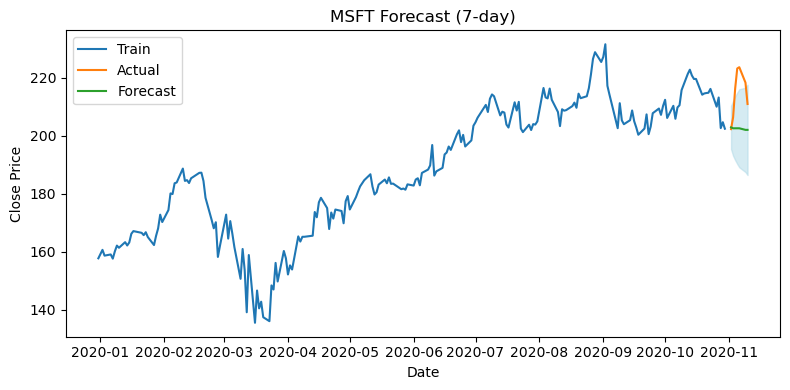

In [158]:
# Doing forcasting for 1, 3 and 7 days ahead
forecast_steps = [1, 3, 7]

# making sure datis in right for and as index
train.index = pd.to_datetime(train.index)
test.index = pd.to_datetime(test.index)

#Function to loop for forecast lengths to forecast and display
for step in forecast_steps:
    #getting the forecast
    pred = results.get_forecast(steps=step, exog=test_exog[:step])
    pred_mean = pred.predicted_mean
    conf_int = pred.conf_int()
    
   # fixing datetime index agin due to odd plots
    if not isinstance(pred_mean.index, pd.DatetimeIndex):
        pred_mean.index = test.index[:step]
        conf_int.index = test.index[:step]
    
    #printing the predicted values
    print(f"\nForecast ({step}-day ahead):")
    print(pred_mean)

    # plot
    plt.figure(figsize=(8, 4))
    plt.plot(train.index, train_close, label='Train')
    plt.plot(test.index[:step], test_close[:step], label='Actual')
    plt.plot(pred_mean.index, pred_mean, label='Forecast')
    plt.fill_between(conf_int.index,
                     conf_int.iloc[:, 0],
                     conf_int.iloc[:, 1], color='lightblue', alpha=0.5)
    plt.title(f'MSFT Forecast ({step}-day)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [159]:
#evaluating accuracy with RMSE
print("\nMSFT ARIMAX RMSE Scores:")
for step in forecast_steps:
    pred = results.get_forecast(steps=step, exog=test_exog[:step])
    pred_mean = pred.predicted_mean

    #fixing datetime index if needed
    if not isinstance(pred_mean.index, pd.DatetimeIndex):
        pred_mean.index = test.index[:step]

    actual = test_close[:step]
    rmse = np.sqrt(mean_squared_error(actual, pred_mean))
    print(f"{step}-day RMSE: {rmse:.2f}")

    #prepare forecast DataFrame so ready for the save function
    df_preds = pd.DataFrame({
        'forecast_made_on': [test.index[0]] * step,
        'day_ahead': list(range(1, step + 1)),
        'forecast': pred_mean.values,
        'actual': actual.values
    })

    #use the save function from before
    save_arima_forecast_with_stock(df_preds, 'MSFT', 'arimax', step)


MSFT ARIMAX RMSE Scores:
1-day RMSE: 0.60
Saved full timeline with forecast: forecast_exports/MSFT_arimax_1d_full.csv
3-day RMSE: 8.26
Saved full timeline with forecast: forecast_exports/MSFT_arimax_3d_full.csv
7-day RMSE: 14.26
Saved full timeline with forecast: forecast_exports/MSFT_arimax_7d_full.csv


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

In [160]:
#adding values to RMSE summary
df_rmse = pd.concat([
    df_rmse,
    pd.DataFrame([
        {'ticker': 'MSFT', 'model': 'arimax', 'horizon': 1, 'rmse': 0.60},
        {'ticker': 'MSFT', 'model': 'arimax', 'horizon': 3, 'rmse': 8.26},
        {'ticker': 'MSFT', 'model': 'arimax', 'horizon': 7, 'rmse': 14.26},
    ])
], ignore_index=True)

In [161]:
#save
df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)
print("RMSE summary updated")

RMSE summary updated


In [163]:
#saving Microsoft daily sentiment
msft_sentiment = df_merged[df_merged['ticker'] == 'MSFT'][['date', 'daily_sentiment']].copy()

#drop duplicates and sort
msft_sentiment = msft_sentiment.drop_duplicates(subset='date')
msft_sentiment = msft_sentiment.sort_values('date')

#save
msft_sentiment.to_csv("forecast_exports/MSFT_sentiment_trend.csv", index=False)
print("Saved: MSFT daily sentiment trend")


Saved: MSFT daily sentiment trend


In [164]:
#highly doubt removing exo will make much of a difference given sparse data but will check next...
# fit ARIMA without exogenous variables
arima_model = SARIMAX(train_close,
                      order=(1, 1, 1),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

arima_results = arima_model.fit(disp=False)
print(arima_results.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  343
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -941.739
Date:                Wed, 14 May 2025   AIC                           1889.477
Time:                        21:15:08   BIC                           1900.964
Sample:                             0   HQIC                          1894.054
                                - 343                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1205      0.212      0.569      0.570      -0.295       0.536
ma.L1         -0.3485      0.199     -1.754      0.079      -0.738       0.041
sigma2        14.9053      0.635     23.469      0.0

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


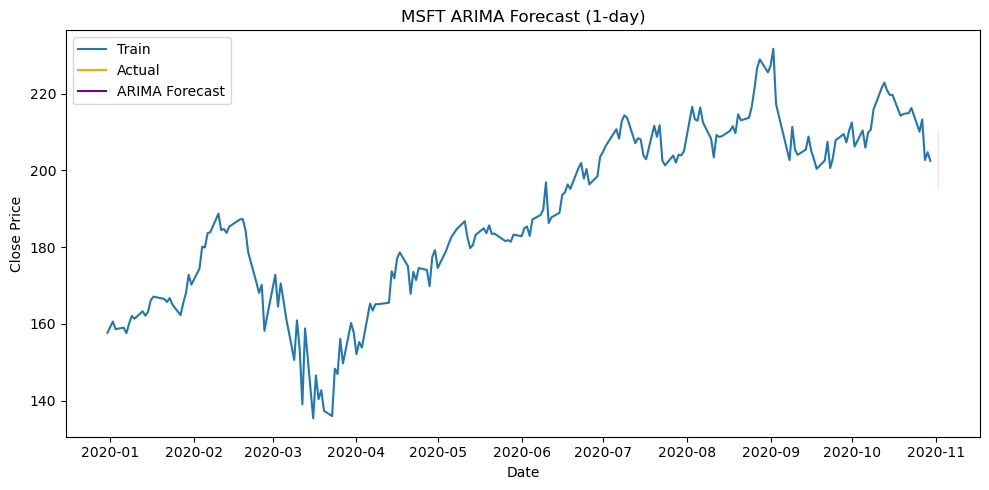

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


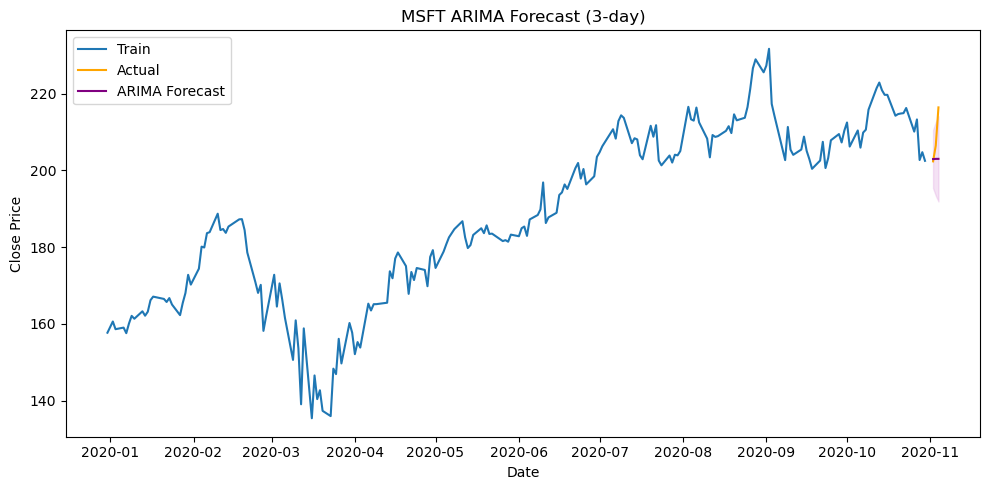

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


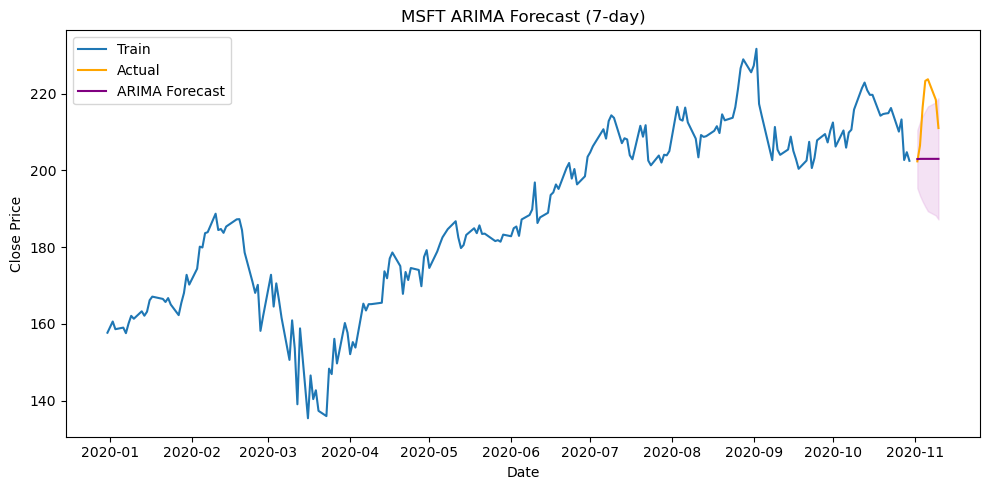

In [165]:
for step in forecast_steps:
    arima_pred = arima_results.get_forecast(steps=step)
    arima_mean = arima_pred.predicted_mean
    arima_conf = arima_pred.conf_int()

    # fixing index again 
    if not isinstance(arima_mean.index, pd.DatetimeIndex):
        arima_mean.index = test.index[:step]
        arima_conf.index = test.index[:step]

    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train_close, label='Train')
    plt.plot(test.index[:step], test_close[:step], label='Actual', color='orange')
    plt.plot(arima_mean.index, arima_mean, label='ARIMA Forecast', color='purple')
    plt.fill_between(arima_conf.index,
                     arima_conf.iloc[:, 0],
                     arima_conf.iloc[:, 1],
                     color='plum', alpha=0.3)
    plt.title(f'MSFT ARIMA Forecast ({step}-day)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [166]:
#Getting RMSE for just ARIMA
print("\nMSFT ARIMA RMSE Scores:")
for step in forecast_steps:
    arima_pred = arima_results.get_forecast(steps=step)
    arima_mean = arima_pred.predicted_mean
    actual = test_close[:step]

    rmse = np.sqrt(mean_squared_error(actual, arima_mean))
    print(f"{step}-day RMSE: {rmse:.2f}")

    df_preds = pd.DataFrame({
        'forecast_made_on': [test.index[0]] * step,
        'day_ahead': list(range(1, step + 1)),
        'forecast': arima_mean.values,
        'actual': actual.values
    })

    save_arima_forecast_with_stock(df_preds, 'MSFT', 'arima', step)


MSFT ARIMA RMSE Scores:
1-day RMSE: 0.59
Saved full timeline with forecast: forecast_exports/MSFT_arima_1d_full.csv
3-day RMSE: 8.00
Saved full timeline with forecast: forecast_exports/MSFT_arima_3d_full.csv
7-day RMSE: 13.81
Saved full timeline with forecast: forecast_exports/MSFT_arima_7d_full.csv


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

In [167]:
#adding Microsoft ARIMA results to RMSE summary
rmse_records = [
    {'ticker': 'MSFT', 'model': 'arima', 'horizon': 1, 'rmse': 0.59},
    {'ticker': 'MSFT', 'model': 'arima', 'horizon': 3, 'rmse': 8.00},
    {'ticker': 'MSFT', 'model': 'arima', 'horizon': 7, 'rmse': 13.81}
]

# append
if 'df_rmse' in globals():
    df_rmse = pd.concat([df_rmse, pd.DataFrame(rmse_records)], ignore_index=True)
else:
    df_rmse = pd.DataFrame(rmse_records)
#save
df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)
print("RMSE summary updated and saved.")


RMSE summary updated and saved.


Accuracy ever so slightly better WITHOUT sentiment data included. Might not use exogeneous variables with ARIMa type models for the other companies as their granger causality tests were very poor. But may try with LSTM for next best p-value (while still showing not significant...) 

### TESLA LSTM
- Has the highest volume of tweets (>4000) 
- Need to difference once to make stationary... granger result suggests causality unlikely (p value 0.2)
- best p value came from lag 7 on daily sentiment... so using that

In [170]:
#looking at Tesla data
tsla = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla['date'] = pd.to_datetime(tsla['date'])
tsla.set_index('date', inplace=True)

#ensure using the correct lag for sentiment (7 by granger test)
tsla['sentiment_lag7'] = tsla['daily_sentiment'].shift(7)
tsla = tsla[['close', 'sentiment_lag7']].dropna()

#normalising features with MixMax scaler on close, sentiment does not need scaling [-1,1] already
close_scaler_7d = MinMaxScaler()
tsla['close_scaled'] = close_scaler_7d.fit_transform(tsla[['close']])
scaled_data_7d = tsla[['close_scaled', 'sentiment_lag7']].values

#converting back to dataframe
scaled_df = pd.DataFrame(scaled_data_7d, index=tsla.index, columns=['close', 'sentiment_lag7'])

In [171]:
#getting rolling windows
def create_sequences(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        seq_x = data[i:i+window_size, :]
        seq_y = data[i+window_size:i+window_size+forecast_horizon, 0]  # only close price
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

# using a 30-day window (for monthly), forecast 1, 3, and 7 days
window_size = 30
X_1d, y_1d = create_sequences(scaled_data_7d, window_size, forecast_horizon=1)
X_3d, y_3d = create_sequences(scaled_data_7d, window_size, forecast_horizon=3)
X_7d, y_7d = create_sequences(scaled_data_7d, window_size, forecast_horizon=7)

In [172]:
#do train test split
train_size_7d = int(len(X_7d) * 0.8) #80% for train

X_7d_train, X_7d_test = X_7d[:train_size_7d], X_7d[train_size_7d:]
y_7d_train, y_7d_test = y_7d[:train_size_7d], y_7d[train_size_7d:]

In [173]:
#building the LSTM model
model_7d = Sequential()
model_7d.add(LSTM(50, activation='relu', input_shape=(window_size, 2)))
model_7d.add(Dropout(0.2))  # helps avoid overfitting
model_7d.add(Dense(7))  # 7-day forecast
model_7d.compile(optimizer='adam', loss='mse')
model_7d.summary()

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │             357 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,957 (42.80 KB)

 Trainable params: 10,957 (42.80 KB)

 Non-trainable params: 0 (0.00 B)

In [174]:
#train
history_7d = model_7d.fit(X_7d_train, y_7d_train, epochs=20, batch_size=16, validation_split=0.1)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0501 - val_loss: 0.0026
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0024 - val_loss: 2.8543e-04
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0021 - val_loss: 2.1310e-04
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0017 - val_loss: 3.9240e-04
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017 - val_loss: 5.0356e-04
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0014 - val_loss: 2.2094e-04
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0013 - val_loss: 8.7767e-04
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0012 - val_loss: 4.8508e-04
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0010 - val_loss: 2.8005e-04
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.6663e-04 - val_loss: 4.0767e-04
Epoch 12/

In [175]:
#making predicitions
y_7d_pred = model_7d.predict(X_7d_test)

# Inverse transform only the predicted close values (sentiment not needed here)
y_7d_pred_rescaled = close_scaler_7d.inverse_transform(y_7d_pred)
y_7d_test_rescaled = close_scaler_7d.inverse_transform(y_7d_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [176]:
#use RMSE to evaluate
rmse_7d = np.sqrt(mean_squared_error(y_7d_test_rescaled, y_7d_pred_rescaled))
print(f"LSTM RMSE (7-day forecast): {rmse_7d:.2f}")

LSTM RMSE (7-day forecast): 5.59


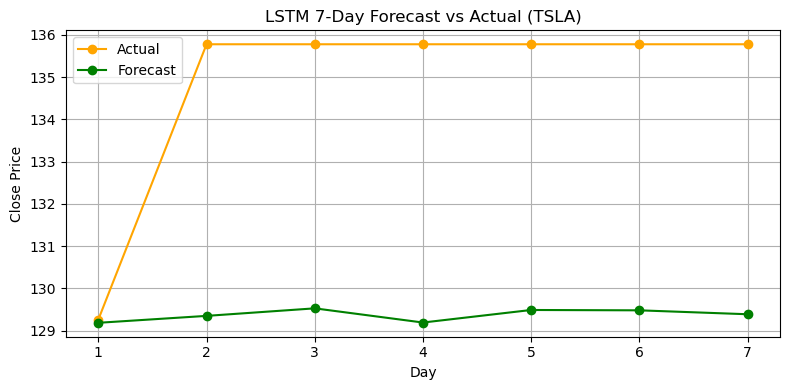

In [177]:
# for simplicity, plotting only the first predicted 7-day window in test set
days_to_plot = 7
start_idx = 0

# getting one forecast window and corresponding actuals
forecast = y_7d_pred_rescaled[start_idx:start_idx + 1].flatten()
actual = y_7d_test_rescaled[start_idx:start_idx + 1].flatten()

# x-axis as future days
future_days = list(range(1, days_to_plot + 1))
#visualising -single forcast plot
plt.figure(figsize=(8, 4))
plt.plot(future_days, actual, marker='o', label='Actual', color='orange')
plt.plot(future_days, forecast, marker='o', label='Forecast', color='green')
plt.title('LSTM 7-Day Forecast vs Actual (TSLA)')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


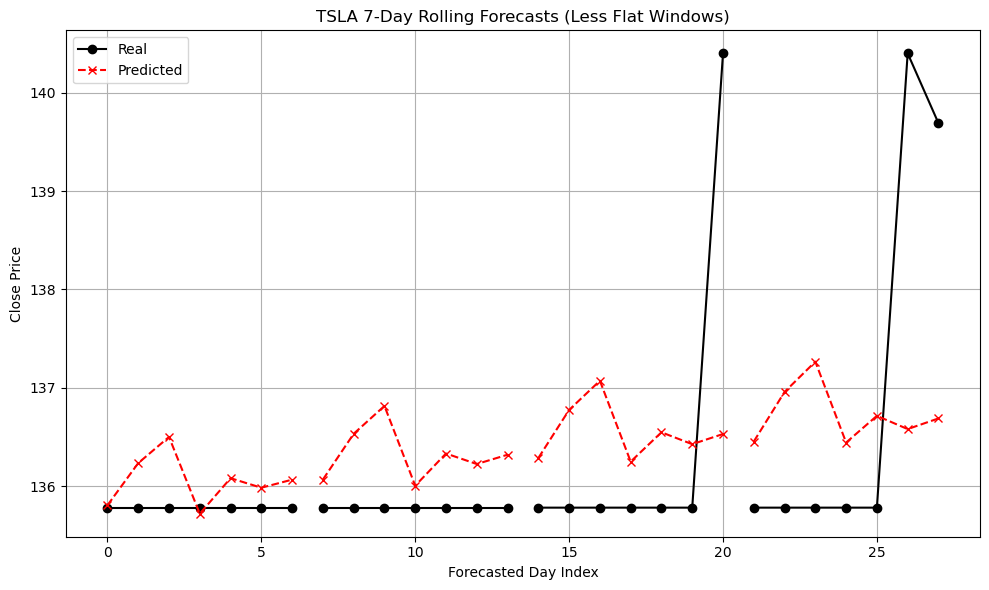

In [178]:
# visualise rolling forecast plot
# Use more interesting section of test set to deal with flatline
start_idx = 10
n_preds = 4  # how many rolling forecasts to show

x_test_final_7d = X_7d_test[start_idx:start_idx + n_preds]
y_test_final_7d = y_7d_test_rescaled[start_idx:start_idx + n_preds]

predictions_7d = model_7d.predict(x_test_final_7d)
preds_7d = close_scaler_7d.inverse_transform(predictions_7d)

plt.figure(figsize=(10, 6))
for i in range(n_preds):
    x_vals = list(range(i * 7, i * 7 + 7))
    plt.plot(x_vals, y_test_final_7d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_7d[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('TSLA 7-Day Rolling Forecasts (Less Flat Windows)')
plt.xlabel('Forecasted Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [179]:
#repeating for 3 day forecast
#do train test split for 3 day
train_size = int(len(X_3d) * 0.8) #80% for train

X_3d_train, X_3d_test = X_3d[:train_size], X_3d[train_size:]
y_3d_train, y_3d_test = y_3d[:train_size], y_3d[train_size:]

In [180]:
#building the LSTM model
model_3d = Sequential()
model_3d.add(LSTM(50, activation='relu', input_shape=(window_size, 2)))
model_3d.add(Dropout(0.2)) #preventing overfitting
model_3d.add(Dense(3))  # output 3 future prices for 3 day forecast
model_3d.compile(optimizer='adam', loss='mse')
model_3d.summary()

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
#train
history_3d = model_3d.fit(X_3d_train, y_3d_train, epochs=20, batch_size=16, validation_split=0.1)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0406 - val_loss: 4.0441e-04
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0031 - val_loss: 3.1136e-04
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0021 - val_loss: 1.9587e-04
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 3.2560e-04
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_loss: 3.4548e-04
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - val_loss: 7.2102e-04
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 4.1692e-04
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 3.1449e-04
Epoch 9/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 1.6238e-04
Epoch 10/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0010 - val_loss: 1.6315e-04
Epoch 11/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.8740e-04 - val_loss: 2.8310e-04
Epoc

In [182]:
#making predicitions
y_3d_pred = model_3d.predict(X_3d_test)
y_3d_pred_rescaled = close_scaler_7d.inverse_transform(y_3d_pred)
y_3d_test_rescaled = close_scaler_7d.inverse_transform(y_3d_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [183]:
#use RMSE to evaluate
rmse_3d = np.sqrt(mean_squared_error(y_3d_test_rescaled, y_3d_pred_rescaled))
print(f"LSTM RMSE (3-day forecast): {rmse_3d:.2f}")

LSTM RMSE (3-day forecast): 5.53


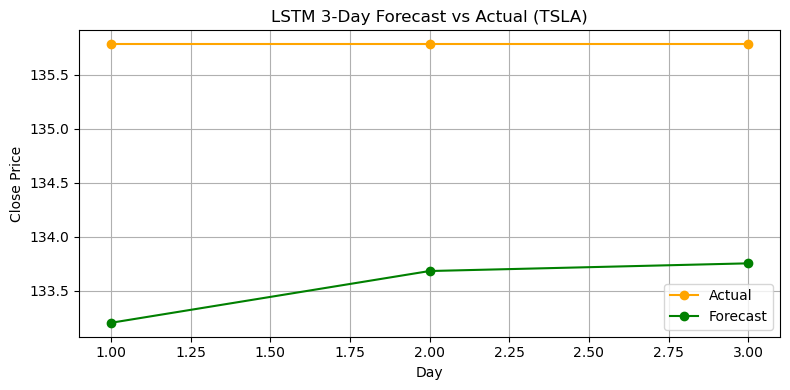

In [184]:
#visualise
plt.figure(figsize=(8, 4))
plt.plot(range(1, 4), y_3d_test_rescaled[0], marker='o', label='Actual', color='orange')
plt.plot(range(1, 4), y_3d_pred_rescaled[0], marker='o', label='Forecast', color='green')
plt.title('LSTM 3-Day Forecast vs Actual (TSLA)')
plt.xlabel('Day')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


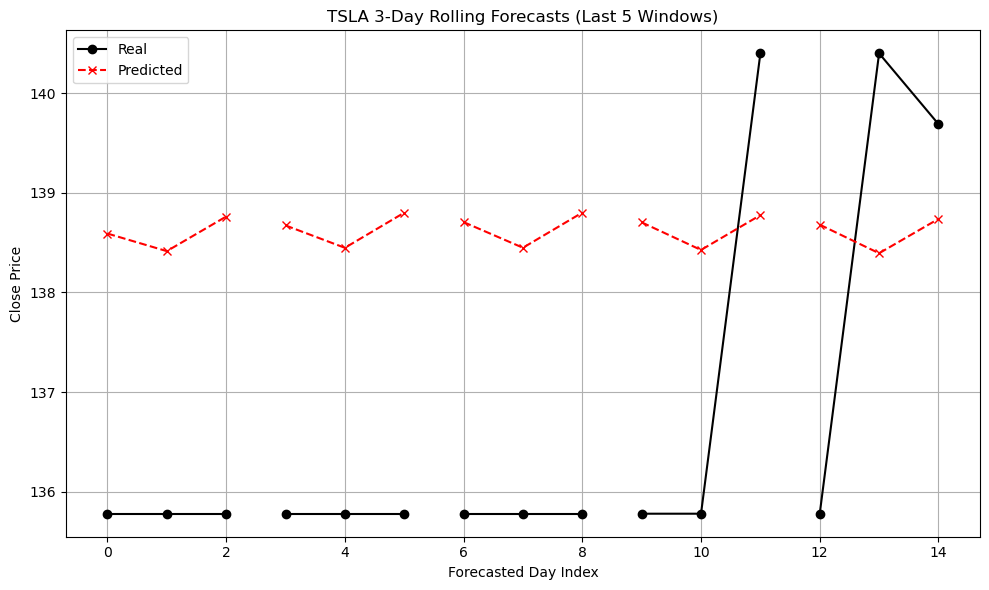

In [185]:
# Look at 4 rolling predictions from the last part of test set
n_preds = 5
start_idx = 10  # picking area with variation so not getting flat line again

x_test_final_3d = X_3d_test[start_idx:start_idx + n_preds]
y_test_final_3d = y_3d_test_rescaled[start_idx:start_idx + n_preds]
predictions_3d = model_3d.predict(x_test_final_3d)
preds_3d = close_scaler_7d.inverse_transform(predictions_3d)

plt.figure(figsize=(10, 6))
for i in range(n_preds):
    x_vals = list(range(i * 3, i * 3 + 3))
    plt.plot(x_vals, y_test_final_3d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_3d[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('TSLA 3-Day Rolling Forecasts (Last 5 Windows)')
plt.xlabel('Forecasted Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [186]:
# getting different data for 1 day.. using lag 1 as RMSE value very poor when usng big window and older sentiment
tsla_1d = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla_1d['date'] = pd.to_datetime(tsla_1d['date'])
tsla_1d.set_index('date', inplace=True)

# using lag 1 sentiment 
tsla_1d['sentiment_lag1'] = tsla_1d['daily_sentiment'].shift(1)
tsla_1d = tsla_1d[['close', 'sentiment_lag1']].dropna()

#scaling again
close_scaler_1d = MinMaxScaler()
tsla_1d['close_scaled'] = close_scaler_1d.fit_transform(tsla_1d[['close']])
scaled_data_1d = tsla_1d[['close_scaled', 'sentiment_lag1']].values

In [187]:
#smaller window this time
window_size_1d = 15  # shorter window
X_1d_new, y_1d_new = create_sequences(scaled_data_1d, window_size_1d, forecast_horizon=1)


#do train test split for 1 day
train_size_1d = int(len(X_1d_new) * 0.8)
X_1d_train, X_1d_test = X_1d_new[:train_size_1d], X_1d_new[train_size_1d:]
y_1d_train, y_1d_test = y_1d_new[:train_size_1d], y_1d_new[train_size_1d:]

In [188]:
#building the LSTM model
model_1d = Sequential()
model_1d.add(LSTM(50, activation='relu', input_shape=(window_size_1d, 2)))
model_1d.add(Dropout(0.2))
model_1d.add(Dense(1))  # Output one future price for 1 day forecast
model_1d.compile(optimizer='adam', loss='mse')
model_1d.summary()

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,651 (41.61 KB)

 Trainable params: 10,651 (41.61 KB)

 Non-trainable params: 0 (0.00 B)

In [189]:
#train
history_1d = model_1d.fit(X_1d_train, y_1d_train, epochs=20, batch_size=16, validation_split=0.1)

Epoch 1/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0354 - val_loss: 2.5606e-04
Epoch 2/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019 - val_loss: 1.2179e-04
Epoch 3/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 4/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0015 - val_loss: 1.2075e-04
Epoch 5/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014 - val_loss: 1.0146e-04
Epoch 6/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - val_loss: 2.6493e-04
Epoch 7/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010 - val_loss: 1.9459e-04
Epoch 8/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0011 - val_loss: 9.6784e-05
Epoch 9/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.2694e-04 - val_loss: 1.1410e-04
Epoch 10/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9096e-04 - val_loss: 8.5068e-05
Epoch 11/20
189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.6518e-04 - val_loss: 4.1996e-04


In [190]:
#making predicitions
y_1d_pred = model_1d.predict(X_1d_test)

# Inverse transform only the predicted close values (sentiment not needed here)
y_1d_pred_rescaled = close_scaler_1d.inverse_transform(y_1d_pred)
y_1d_test_rescaled = close_scaler_1d.inverse_transform(y_1d_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [191]:
#use RMSE to evaluate
rmse_1d = np.sqrt(mean_squared_error(y_1d_test_rescaled, y_1d_pred_rescaled))
print(f"LSTM RMSE (1-day forecast): {rmse_1d:.2f}")

LSTM RMSE (1-day forecast): 4.23


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


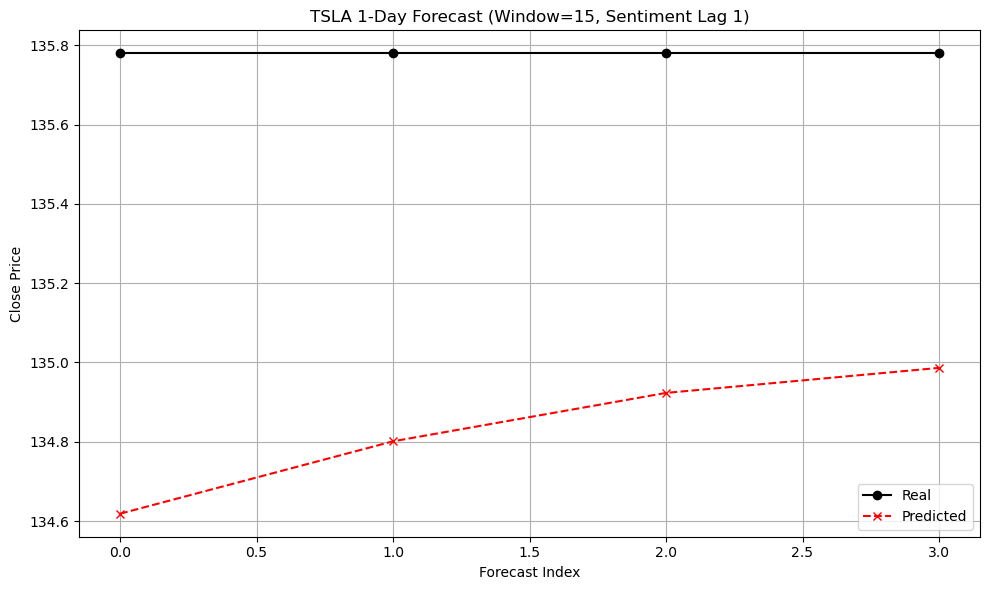

In [192]:
# Look at rolling predictions from the last part of test set... no point in doing single forcast plot
n_preds = 4
start_idx = 10 #more interestnig period than start

#geteing last window of data to forecast from
x_test_final_1d = X_1d_test[start_idx:start_idx + n_preds]
y_test_final_1d = y_1d_test_rescaled[start_idx:start_idx + n_preds]

# get predictions
predictions_1d = model_1d.predict(x_test_final_1d)
preds_1d = close_scaler_1d.inverse_transform(predictions_1d)

# plot
plt.figure(figsize=(10, 6))
plt.plot(range(n_preds), y_test_final_1d, color='black', marker='o', label='Real')
plt.plot(range(n_preds), preds_1d, color='red', marker='x', linestyle='--', label='Predicted')
plt.title('TSLA 1-Day Forecast (Window=15, Sentiment Lag 1)')
plt.xlabel('Forecast Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [193]:
# 1 day is suprisingly poor for RMSE... looking at predictions# could just be due to volitile period in testing bit
for i in range(5):
    actual = y_1d_test_rescaled[i][0]
    predicted = y_1d_pred_rescaled[i][0]
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f} | Diff: {abs(actual - predicted):.2f}")

Actual: 129.26 | Predicted: 129.20 | Diff: 0.06
Actual: 135.78 | Predicted: 129.20 | Diff: 6.58
Actual: 135.78 | Predicted: 129.99 | Diff: 5.79
Actual: 135.78 | Predicted: 130.99 | Diff: 4.79
Actual: 135.78 | Predicted: 131.82 | Diff: 3.96


In [194]:
# saving 1 day forecast 
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_1d_test_rescaled,
    y_pred_rescaled=y_1d_pred_rescaled,
    ticker='TSLA',
    model_name='lstm',
    horizon=1,
    window_dates=tsla.index[window_size:],  
    start_idx=train_size_7d,  
    n_preds=len(y_1d_pred_rescaled)
)

# Saving 3 day 
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_3d_test_rescaled,
    y_pred_rescaled=y_3d_pred_rescaled,
    ticker='TSLA',
    model_name='lstm',
    horizon=3,
    window_dates=tsla.index[window_size:],
    start_idx=train_size_7d,
    n_preds=len(y_3d_pred_rescaled)
)

# saving LSTM 7-day rolling forecasts
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_7d_test_rescaled,
    y_pred_rescaled=y_7d_pred_rescaled,
    ticker='TSLA',
    model_name='lstm',
    horizon=7,
    window_dates=tsla.index[window_size:],
    start_idx=train_size_7d,
    n_preds=len(y_7d_pred_rescaled)
)

Saved full timeline with forecast: forecast_exports/TSLA_lstm_1d_full.csv
Saved full timeline with forecast: forecast_exports/TSLA_lstm_3d_full.csv
Saved full timeline with forecast: forecast_exports/TSLA_lstm_7d_full.csv


In [195]:
#rolling forecast formatter
def save_lstm_rolling_forecast(X_test, y_true_rescaled, y_pred_rescaled, ticker, model_name, horizon, window_dates, start_idx=0, n_preds=5):
    """
    Saves rolling LSTM forecast in long format:
    forecast_made_on | day_ahead | actual | forecast | ticker | model | horizon
    """
    
    records = []

    for i in range(n_preds):
        made_on = window_dates[start_idx + i]
        for day in range(horizon):
            try:
                actual = y_true_rescaled[start_idx + i][day]
                forecast = y_pred_rescaled[start_idx + i][day]
                records.append({
                    'forecast_made_on': made_on,
                    'day_ahead': day + 1,
                    'actual': actual,
                    'forecast': forecast,
                    'ticker': ticker,
                    'model': model_name,
                    'horizon': horizon
                })
            except IndexError:
                continue  # skipping incomplete window at the end

    df = pd.DataFrame(records)

    os.makedirs("forecast_exports", exist_ok=True)
    filename = f"forecast_exports/{ticker}_{model_name}_{horizon}d.csv"
    df.to_csv(filename, index=False)
    print(f" Saved: {filename}")

In [196]:
# saving LSTM tesla RSMe
rmse_records = [
    {'ticker': 'TSLA', 'model': 'lstm', 'horizon': 1, 'rmse': rmse_1d},
    {'ticker': 'TSLA', 'model': 'lstm', 'horizon': 3, 'rmse': rmse_3d},
    {'ticker': 'TSLA', 'model': 'lstm', 'horizon': 7, 'rmse': rmse_7d},
]

# Load existing if needed
rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame(rmse_records)], ignore_index=True)
else:
    df_rmse = pd.DataFrame(rmse_records)

df_rmse.to_csv(rmse_path, index=False)
print("RMSE summary updated and saved.")

RMSE summary updated and saved.


In [197]:
#saving daily sentiment
tsla_sentiment_trend = df_merged[df_merged['ticker'] == 'TSLA'][['date', 'daily_sentiment']]
tsla_sentiment_trend = tsla_sentiment_trend.groupby('date').mean().reset_index()

tsla_sentiment_trend.to_csv("forecast_exports/TSLA_sentiment_trend.csv", index=False)
print("TSLA sentiment trend saved.")

TSLA sentiment trend saved.


RMSE for 1 day is quite poor... going to look at reducing the window size... given that its a very short term predicition and using a fresher sentiment value (lag 1 instead of 7... as LSTM may not be as fussed with granger test results as ARIMa was)

Chnaing the windows etc did not hav much of an effect of accuracy for 1 day... going to try XG Boost for 1 day

Looks like It could be overfitting... flat lines have me worried for tesla stock data and i'f i've muddled it up... confused by flat line... but may just be that last few stock values are the same... 

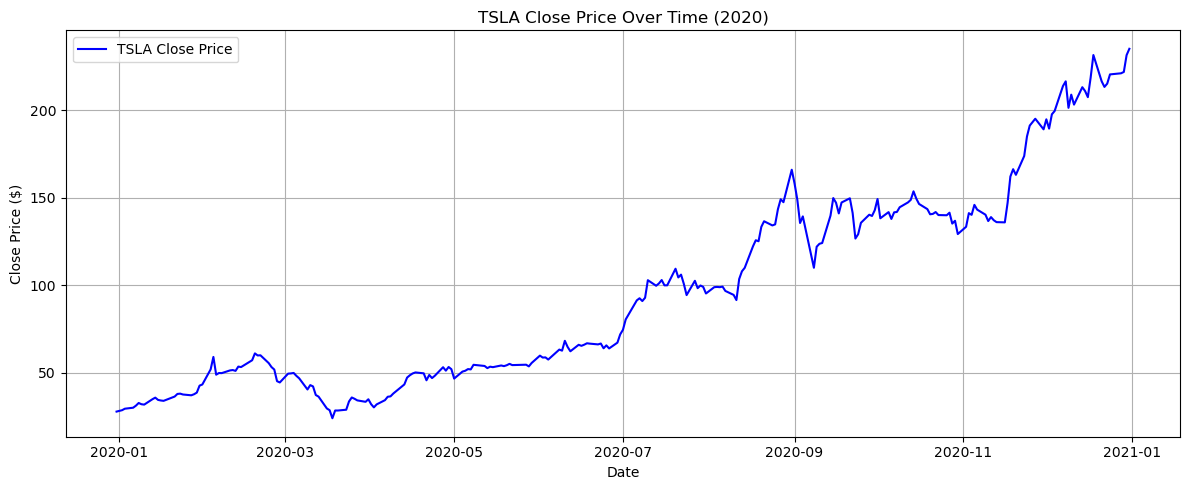

In [200]:
#checking have I messed up the stock data
# Filter Tesla stock data
tsla = df_merged[df_merged['ticker'] == 'TSLA'].copy()

# Ensure date is datetime and sorted
tsla['date'] = pd.to_datetime(tsla['date'])
tsla = tsla.sort_values('date')

# Plot Close price
plt.figure(figsize=(12, 5))
plt.plot(tsla['date'], tsla['close'], label='TSLA Close Price', color='blue')
plt.title('TSLA Close Price Over Time (2020)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [201]:
#retrying 1 day forecast for TSLa with XGBoost
#getting the data ready
tsla = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla['date'] = pd.to_datetime(tsla['date'])
tsla.set_index('date', inplace=True)

#using 1 day lag on sentiment again
tsla['sentiment_lag1'] = tsla['daily_sentiment'].shift(1) #non linear don't need to go with best lag from Granger test.. can test others if poor RMSE

# Create lag features for close price (using last 15days as window again)
for lag in range(1, 16):
    tsla[f'lag_{lag}'] = tsla['close'].shift(lag)

tsla = tsla.dropna()

In [202]:
#features and target 
feature_cols = [f'lag_{lag}' for lag in range(1, 16)] + ['sentiment_lag1']
X = tsla[feature_cols].values
y = tsla['close'].values

In [203]:
#train test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [204]:
#training the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [205]:
#predicting and evaluating
y_pred = xgb_model.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred, squared=False)
print(f"XGBoost RMSE (1-day forecast): {rmse_xgb:.2f}")

XGBoost RMSE (1-day forecast): 35.11


C:\Users\orlak\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


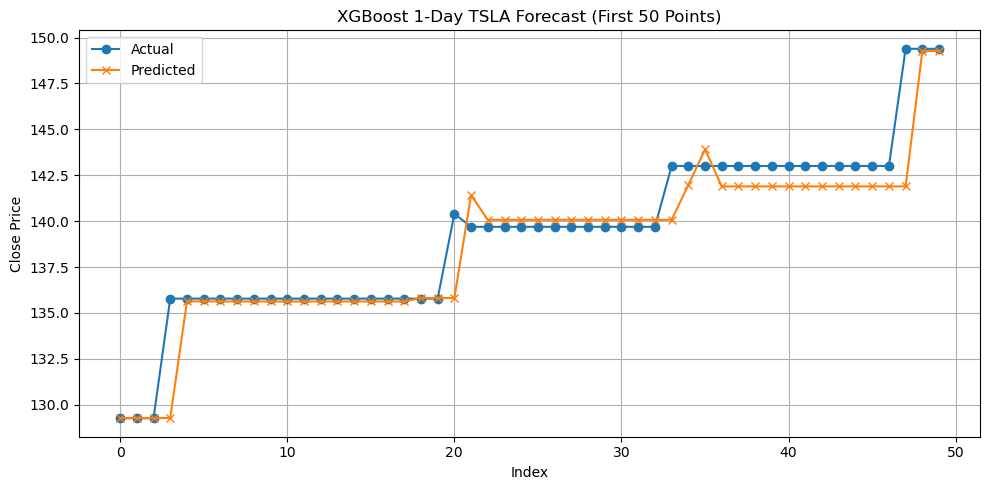

In [206]:
#forecast plot
plt.figure(figsize=(10, 5))
plt.plot(y_test[:50], label='Actual', marker='o')
plt.plot(y_pred[:50], label='Predicted', marker='x')
plt.title('XGBoost 1-Day TSLA Forecast (First 50 Points)')
plt.xlabel('Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Going by RMS result... XGBoost was definitelynot a better fit

In [208]:
#saving XGBoost dataframe for plottng actual vs forecast in dshboard
def save_flat_forecast_with_stock(df_forecast, ticker, model_name, horizon):
    df_filtered = df_merged[df_merged['ticker'] == ticker].copy()
    df_filtered['date'] = pd.to_datetime(df_filtered['date'])
    df_filtered.set_index('date', inplace=True)

    df_full = pd.DataFrame({
        'date': df_filtered.index,
        'close': df_filtered['close'],
    })

    if 'weekly_sentiment' in df_filtered.columns:
        df_full['weekly_sentiment'] = df_filtered['weekly_sentiment'].values
    if 'daily_sentiment' in df_filtered.columns:
        df_full['daily_sentiment'] = df_filtered['daily_sentiment'].values

    col_name = f"{model_name}_{horizon}d"
    df_full[col_name] = np.nan

    for idx, row in df_forecast.iterrows():
        match = df_full['date'] == idx
        df_full.loc[match, col_name] = row['forecast']

    os.makedirs("forecast_exports", exist_ok=True)
    df_full.to_csv(f"forecast_exports/{ticker}_{model_name}_{horizon}d_full.csv", index=False)
    print(f"Saved full timeline with forecast: forecast_exports/{ticker}_{model_name}_{horizon}d_full.csv")
    
df_xgb_1d = pd.DataFrame({
    'date': tsla.index[-len(y_test):],  # match test period
    'actual': y_test,
    'forecast': y_pred
})
df_xgb_1d.set_index('date', inplace=True)

save_flat_forecast_with_stock(df_xgb_1d, ticker='TSLA', model_name='xgboost', horizon=1)

Saved full timeline with forecast: forecast_exports/TSLA_xgboost_1d_full.csv


In [209]:
#add in RSME value to dataframe
rmse_records.append({'ticker': 'TSLA', 'model': 'xgboost', 'horizon': 1, 'rmse': rmse_xgb})

## Apple LSTM
repeating code again, only using rolling window plot this time, using sentiment lag suggested by granger.. althouh possibly not stritly necessary...won't hurt!

In [211]:
#setting up data for Apple
aapl = df_merged[df_merged['ticker'] == 'AAPL'].copy()
aapl['date'] = pd.to_datetime(aapl['date'])
aapl.set_index('date', inplace=True)

#using daily sentiment with lag 3 (based on Granger result)
aapl['sentiment_lag3'] = aapl['daily_sentiment'].shift(3)
aapl = aapl[['close', 'sentiment_lag3']].dropna()

#scaling close price only
close_scaler_aapl = MinMaxScaler()
aapl['close_scaled'] = close_scaler_aapl.fit_transform(aapl[['close']])

#getting scaled dataframe
scaled_data_aapl = aapl[['close_scaled', 'sentiment_lag3']].values

In [212]:
#creating sequences for 1,3 and 7 day forecasts
def create_sequences(data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+forecast_horizon, 0])
    return np.array(X), np.array(y)

window_size_aapl = 15

X_1d_aapl, y_1d_aapl = create_sequences(scaled_data_aapl, window_size_aapl, forecast_horizon=1)
X_3d_aapl, y_3d_aapl = create_sequences(scaled_data_aapl, window_size_aapl, forecast_horizon=3)
X_7d_aapl, y_7d_aapl = create_sequences(scaled_data_aapl, window_size_aapl, forecast_horizon=7)

In [213]:
#1 day train/test/split
split_1d = int(len(X_1d_aapl) * 0.8)
X_1d_train_aapl, X_1d_test_aapl = X_1d_aapl[:split_1d], X_1d_aapl[split_1d:]
y_1d_train_aapl, y_1d_test_aapl = y_1d_aapl[:split_1d], y_1d_aapl[split_1d:]

In [214]:
#building model for 1 day LSTM
model_1d_aapl = Sequential()
model_1d_aapl.add(LSTM(50, activation='relu', input_shape=(window_size_aapl, 2)))
model_1d_aapl.add(Dropout(0.2))
model_1d_aapl.add(Dense(1))
model_1d_aapl.compile(optimizer='adam', loss='mse')
model_1d_aapl.summary()

history_1d_aapl = model_1d_aapl.fit(
    X_1d_train_aapl, y_1d_train_aapl,
    epochs=20, batch_size=16, validation_split=0.1
)

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,651 (41.61 KB)

 Trainable params: 10,651 (41.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1656 - val_loss: 0.0013
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0069 - val_loss: 0.0011
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0062 - val_loss: 0.0010
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 6.9555e-04
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0056 - val_loss: 0.0025
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0049 - val_loss: 8.6282e-04
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 - val_loss: 0.0020
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - val_loss: 8.3013e-04
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 6.4729e-04
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - val_loss: 0.0024
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0045 - val_loss: 0.0017
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss

In [215]:
# 1 day predictions and evaluations
y_1d_pred_aapl = model_1d_aapl.predict(X_1d_test_aapl)
y_1d_test_rescaled_aapl = close_scaler_aapl.inverse_transform(y_1d_test_aapl)
y_1d_pred_rescaled_aapl = close_scaler_aapl.inverse_transform(y_1d_pred_aapl)

rmse_1d_aapl = np.sqrt(mean_squared_error(y_1d_test_rescaled_aapl, y_1d_pred_rescaled_aapl))
print(f"AAPL 1-Day LSTM RMSE: {rmse_1d_aapl:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
AAPL 1-Day LSTM RMSE: 1.89


In [218]:
#rolling forecast plot for 1 day forecast
n_preds_1d = 4
start_idx_1d = 0  

# Get correct test dates from the end of AAPL (same size as test set)
test_index_dates_1d = aapl.index[-X_1d_test_aapl.shape[0]:]
rolling_window_dates_1d = test_index_dates_1d[start_idx_1d : start_idx_1d + n_preds_1d]

#saving forecast
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_1d_test_rescaled_aapl,
    y_pred_rescaled=y_1d_pred_rescaled_aapl,
    ticker='AAPL',
    model_name='lstm',
    horizon=1,
    window_dates=aapl.index[window_size_aapl:],  # same logic as Tesla
    start_idx=split_1d,
    n_preds=len(y_1d_pred_rescaled_aapl)
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_1d_full.csv


In [231]:
# 3 day forecast train/test/split
split_3d = int(len(X_3d_aapl) * 0.8)
X_3d_train_aapl, X_3d_test_aapl = X_3d_aapl[:split_3d], X_3d_aapl[split_3d:]
y_3d_train_aapl, y_3d_test_aapl = y_3d_aapl[:split_3d], y_3d_aapl[split_3d:]

In [232]:
#LSTM model
model_3d_aapl = Sequential()
model_3d_aapl.add(LSTM(50, activation='relu', input_shape=(15, 2)))
model_3d_aapl.add(Dropout(0.2))
model_3d_aapl.add(Dense(3))  # 3 day forecast
model_3d_aapl.compile(optimizer='adam', loss='mse')
model_3d_aapl.summary()

history_3d_aapl = model_3d_aapl.fit(
    X_3d_train_aapl, y_3d_train_aapl,
    epochs=20, batch_size=16, validation_split=0.1
)

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 3)                   │             153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1760 - val_loss: 0.0072
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0133 - val_loss: 0.0039
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0098 - val_loss: 0.0017
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0087 - val_loss: 0.0034
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0074 - val_loss: 0.0015
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - val_loss: 8.8785e-04
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0060 - val_loss: 0.0022
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0060 - val_loss: 9.1161e-04
Epoch 9/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0054 - val_loss: 0.0014
Epoch 10/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0062 - val_loss: 0.0013
Epoch 11/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0050 - val_loss: 7.8476e-04
Epoch 12/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.

In [234]:
#predicting and evaluating
y_3d_pred_aapl = model_3d_aapl.predict(X_3d_test_aapl)
y_3d_test_rescaled_aapl = close_scaler_aapl.inverse_transform(y_3d_test_aapl)
y_3d_pred_rescaled_aapl = close_scaler_aapl.inverse_transform(y_3d_pred_aapl)

rmse_3d_aapl = np.sqrt(mean_squared_error(y_3d_test_rescaled_aapl, y_3d_pred_rescaled_aapl))
print(f"AAPL 3-Day LSTM RMSE: {rmse_3d_aapl:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
AAPL 3-Day LSTM RMSE: 2.13


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


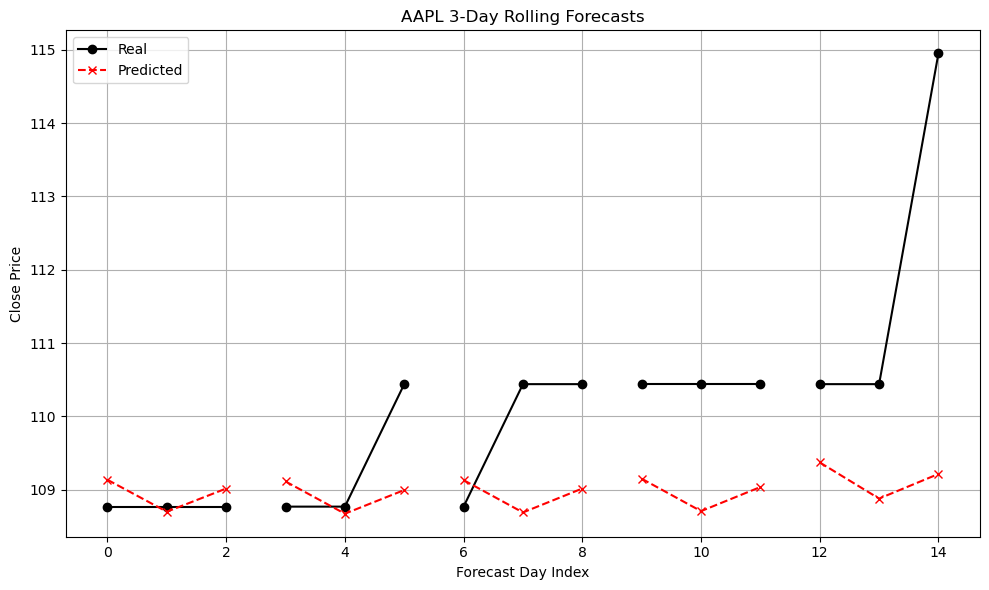

In [235]:
# plot
n_preds_3d = 5
start_idx_3d = 125

x_test_final_3d = X_3d_test_aapl[start_idx_3d:start_idx_3d + n_preds_3d]
y_test_final_3d = y_3d_test_rescaled_aapl[start_idx_3d:start_idx_3d + n_preds_3d]

predictions_3d = model_3d_aapl.predict(x_test_final_3d)
preds_3d = close_scaler_aapl.inverse_transform(predictions_3d)

# Plot forecast vs actual
plt.figure(figsize=(10, 6))
for i in range(n_preds_3d):
    x_vals = list(range(i * 3, i * 3 + 3))
    plt.plot(x_vals, y_test_final_3d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_3d[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('AAPL 3-Day Rolling Forecasts')
plt.xlabel('Forecast Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [236]:
#saving 3 day forcast rolling
n_preds_3d = 5
start_idx_3d = 0  # start at beginning of test set

#getting date index from test portion of AAPL data
test_index_dates_3d = aapl.index[-X_3d_test_aapl.shape[0]:]
rolling_window_dates_3d = test_index_dates_3d[start_idx_3d : start_idx_3d + n_preds_3d]

#saving forecast
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_3d_test_rescaled_aapl,
    y_pred_rescaled=y_3d_pred_rescaled_aapl,
    ticker='AAPL',
    model_name='lstm',
    horizon=3,
    window_dates=aapl.index[window_size_aapl:],  # reuse same index logic
    start_idx=split_3d,
    n_preds=len(y_3d_pred_rescaled_aapl)
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_3d_full.csv


In [237]:
# 7 day forcast train/test/split
split_7d = int(len(X_7d_aapl) * 0.8)
X_7d_train_aapl, X_7d_test_aapl = X_7d_aapl[:split_7d], X_7d_aapl[split_7d:]
y_7d_train_aapl, y_7d_test_aapl = y_7d_aapl[:split_7d], y_7d_aapl[split_7d:]

In [238]:
# LSTM for 7 day forecast
model_7d_aapl = Sequential()
model_7d_aapl.add(LSTM(50, activation='relu', input_shape=(15, 2)))
model_7d_aapl.add(Dropout(0.2))
model_7d_aapl.add(Dense(7))  # getting 7 future prices
model_7d_aapl.compile(optimizer='adam', loss='mse')
model_7d_aapl.summary()
#training
history_7d_aapl = model_7d_aapl.fit(
    X_7d_train_aapl, y_7d_train_aapl,
    epochs=20, batch_size=16, validation_split=0.1
)

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 50)                  │          10,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             357 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,957 (42.80 KB)

 Trainable params: 10,957 (42.80 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2003 - val_loss: 0.0104
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 - val_loss: 0.0072
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0127 - val_loss: 0.0030
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0098 - val_loss: 0.0051
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 - val_loss: 0.0016
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - val_loss: 0.0017
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - val_loss: 0.0012
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0073 - val_loss: 0.0035
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069 - val_loss: 0.0011
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061 - val_loss: 0.0011
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0053 - val_loss: 0.0012
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053 - val_l

In [239]:
# predict and evaluate
y_7d_pred_aapl = model_7d_aapl.predict(X_7d_test_aapl)

# rescale
y_7d_test_rescaled_aapl = close_scaler_aapl.inverse_transform(y_7d_test_aapl)
y_7d_pred_rescaled_aapl = close_scaler_aapl.inverse_transform(y_7d_pred_aapl)

rmse_7d_aapl = np.sqrt(mean_squared_error(y_7d_test_rescaled_aapl, y_7d_pred_rescaled_aapl))
print(f"AAPL 7-Day LSTM RMSE: {rmse_7d_aapl:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
AAPL 7-Day LSTM RMSE: 2.85


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


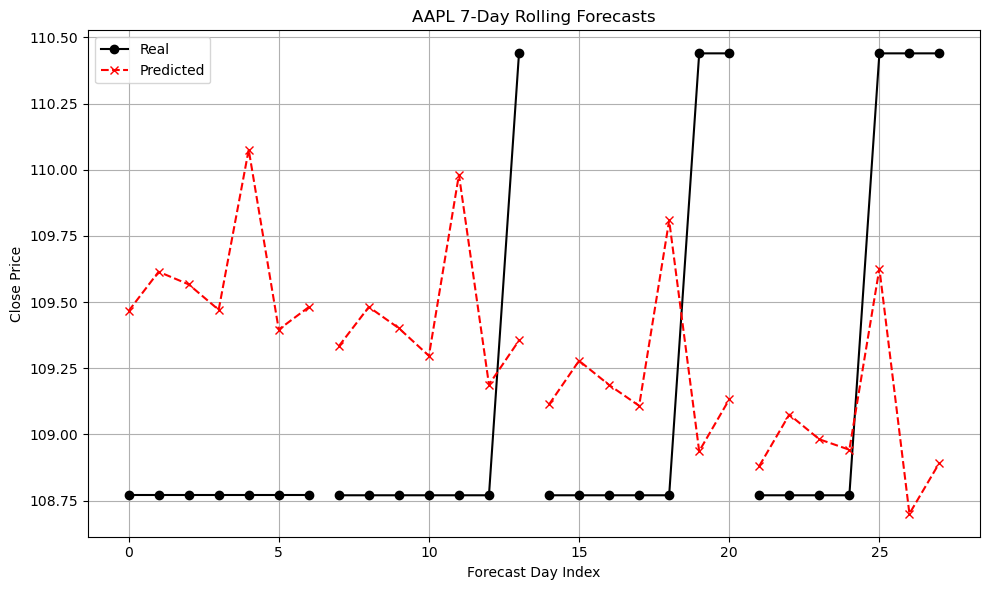

In [240]:
#plot
n_preds_7d = 4
start_idx_7d = 125

x_test_final_7d = X_7d_test_aapl[start_idx_7d:start_idx_7d + n_preds_7d]
y_test_final_7d = y_7d_test_rescaled_aapl[start_idx_7d:start_idx_7d + n_preds_7d]

predictions_7d = model_7d_aapl.predict(x_test_final_7d)
preds_7d = close_scaler_aapl.inverse_transform(predictions_7d)

plt.figure(figsize=(10, 6))
for i in range(n_preds_7d):
    x_vals = list(range(i * 7, i * 7 + 7))
    plt.plot(x_vals, y_test_final_7d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_7d[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('AAPL 7-Day Rolling Forecasts')
plt.xlabel('Forecast Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [241]:
#saving 7 day rolling
n_preds_7d = 5
start_idx_7d = 0  #avoiding 125 error

#getting index dates
test_index_dates_7d = aapl.index[-X_7d_test_aapl.shape[0]:]
rolling_window_dates_7d = test_index_dates_7d[start_idx_7d : start_idx_7d + n_preds_7d]

#saving
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_7d_test_rescaled_aapl,
    y_pred_rescaled=y_7d_pred_rescaled_aapl,
    ticker='AAPL',
    model_name='lstm',
    horizon=7,
    window_dates=aapl.index[window_size_aapl:],  # same logic as Tesla
    start_idx=split_7d,
    n_preds=len(y_7d_pred_rescaled_aapl)
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_7d_full.csv


In [242]:
# saving AAPL LSTM RMSE scores
rmse_records = [
    {'ticker': 'AAPL', 'model': 'lstm', 'horizon': 1, 'rmse': rmse_1d_aapl},
    {'ticker': 'AAPL', 'model': 'lstm', 'horizon': 3, 'rmse': rmse_3d_aapl},
    {'ticker': 'AAPL', 'model': 'lstm', 'horizon': 7, 'rmse': rmse_7d_aapl},
]

#load existing summary 
rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame(rmse_records)], ignore_index=True)
else:
    df_rmse = pd.DataFrame(rmse_records)

#save back to file
df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)
print("RMSE summary updated with AAPL LSTM results")


RMSE summary updated with AAPL LSTM results


In [243]:
#saving daily sentiment for apple
#filter daily sentiment for AAPL and drop NAs
aapl_sentiment = df_merged[df_merged['ticker'] == 'AAPL'][['date', 'daily_sentiment']].dropna()

#dropping duplicates (if any)
aapl_sentiment = aapl_sentiment.drop_duplicates()

#save
aapl_sentiment.to_csv("forecast_exports/AAPL_sentiment_trend.csv", index=False)
print("AAPL daily sentiment trend saved")


AAPL daily sentiment trend saved


Reloading Tuner from lstm_tuning\aapl_1d\tuner0.json



C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          17,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

Results summary
Results in lstm_tuning\aapl_1d
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 2 summary
Hyperparameters:
units: 64
dropout: 0.1
Score: 0.00050146589637734

Trial 0 summary
Hyperparameters:
units: 64
dropout: 0.5
Score: 0.0005256217264104635

Trial 1 summary
Hyperparameters:
units: 128
dropout: 0.30000000000000004
Score: 0.0005611289816442877

Trial 4 summary
Hyperparameters:
units: 32
dropout: 0.30000000000000004
Score: 0.0006794876244384795

Trial 3 summary
Hyperparameters:
units: 96
dropout: 0.4
Score: 0.0007288070628419518
Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0019 - val_loss: 5.1565e-04
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0017 - val_loss: 8.6471e-04
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 4.8816e-04
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0018 - val_loss: 4.1183e-04
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0015 - val_l

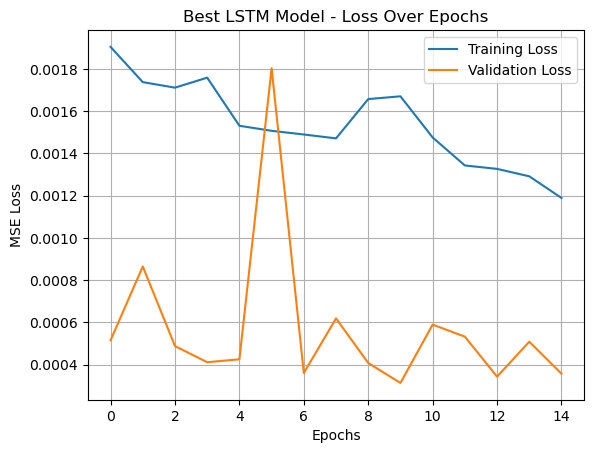

In [244]:
# Define model-building function
def build_model(hp):
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(window_size_aapl, 2)
    ))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Set up tuner
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    directory='lstm_tuning',
    project_name='aapl_1d'
)

# Run tuner search
tuner.search(
    X_1d_train_aapl, y_1d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

# Retrieve the best model
model_1d_aapl_tuned = tuner.get_best_models(num_models=1)[0]
model_1d_aapl_tuned.summary()

# Optional: Plot validation loss for all trials
tuner.results_summary()

# Train the best model if needed (can skip if tuner trained it enough)
history = model_1d_aapl_tuned.fit(
    X_1d_train_aapl, y_1d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)]
)

# Plot training vs validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Best LSTM Model - Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [245]:
#get predictions
y_1d_pred_tuned = model_1d_aapl_tuned.predict(X_1d_test_aapl)
y_1d_pred_rescaled_tuned = close_scaler_aapl.inverse_transform(y_1d_pred_tuned)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


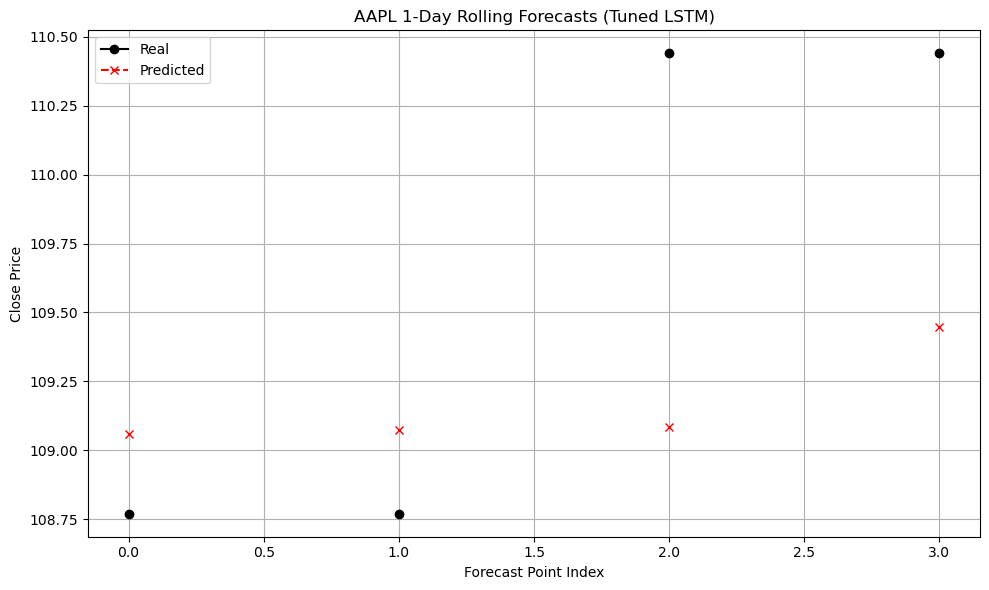

In [246]:
# tuned 1d rolling forecast plot
n_preds_1d = 4
start_idx_1d = 125  # adjusting to avoid index error

#inputs
x_test_final_1d = X_1d_test_aapl[start_idx_1d:start_idx_1d + n_preds_1d]
y_test_final_1d = y_1d_test_rescaled_aapl[start_idx_1d:start_idx_1d + n_preds_1d]

#predicting with tuned model
predictions_1d_tuned = model_1d_aapl_tuned.predict(x_test_final_1d)
preds_1d_tuned = close_scaler_aapl.inverse_transform(predictions_1d_tuned)

#plotting rolling predicts
plt.figure(figsize=(10, 6))
for i in range(n_preds_1d):
    x_vals = [i]  # single day forecast
    plt.plot(x_vals, [y_test_final_1d[i]], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, [preds_1d_tuned[i]], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('AAPL 1-Day Rolling Forecasts (Tuned LSTM)')
plt.xlabel('Forecast Point Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [247]:
#save forecast
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_1d_test_rescaled_aapl,
    y_pred_rescaled=y_1d_pred_rescaled_tuned,
    ticker='AAPL',
    model_name='lstm',
    horizon=1,
    window_dates=aapl.index[window_size_aapl:],
    start_idx=split_1d,
    n_preds=len(y_1d_pred_rescaled_tuned),
    tuned=True #setting as a tuned model
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_1d_full_tuned.csv


In [248]:
#save RMSE
rmse_1d_aapl_tuned = np.sqrt(mean_squared_error(y_1d_test_rescaled_aapl, y_1d_pred_rescaled_tuned))

rmse_record = {
    'ticker': 'AAPL',
    'model': 'lstm_tuned',
    'horizon': 1,
    'rmse': rmse_1d_aapl_tuned
}

#adding to existing RMSE summary
rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame([rmse_record])], ignore_index=True)
else:
    df_rmse = pd.DataFrame([rmse_record])

df_rmse.to_csv(rmse_path, index=False)
print("RMSE summary updated with AAPL 1-day tuned result.")

RMSE summary updated with AAPL 1-day tuned result.


In [249]:
#3 day tuned model
def build_model_3d(hp):
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(window_size_aapl, 2)
    ))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(3))  # 3-day forecast
    model.compile(optimizer='adam', loss='mse')
    return model

#setting up the tuner
tuner_3d = RandomSearch(
    build_model_3d,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    directory='lstm_tuning',
    project_name='aapl_3d'
)

#running tuner
tuner_3d.search(
    X_3d_train_aapl, y_3d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

#setting up best model from tuning
model_3d_aapl_tuned = tuner_3d.get_best_models(num_models=1)[0]
model_3d_aapl_tuned.summary()
#train

history_3d = model_3d_aapl_tuned.fit(
    X_3d_train_aapl, y_3d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)]
)

Reloading Tuner from lstm_tuning\aapl_3d\tuner0.json


C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 128)                 │          67,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,459 (263.51 KB)

 Trainable params: 67,459 (263.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0022 - val_loss: 0.0017
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 6.6682e-04
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 7.1568e-04
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0016 - val_loss: 6.5715e-04
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018 - val_loss: 8.4550e-04
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 6.8745e-04
Epoch 9/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0018 - val_loss: 0.0018
Epoch 10/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0016 - val_loss: 9.8439e-04
Epoch 11/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015 - val_loss: 5.8404e-04
Epoch 12/30
73/73 ━━━━━━━━━━━━━━━━━━

In [250]:
#get predictions
y_3d_pred_tuned = model_3d_aapl_tuned.predict(X_3d_test_aapl)
y_3d_pred_rescaled_tuned = close_scaler_aapl.inverse_transform(y_3d_pred_tuned)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


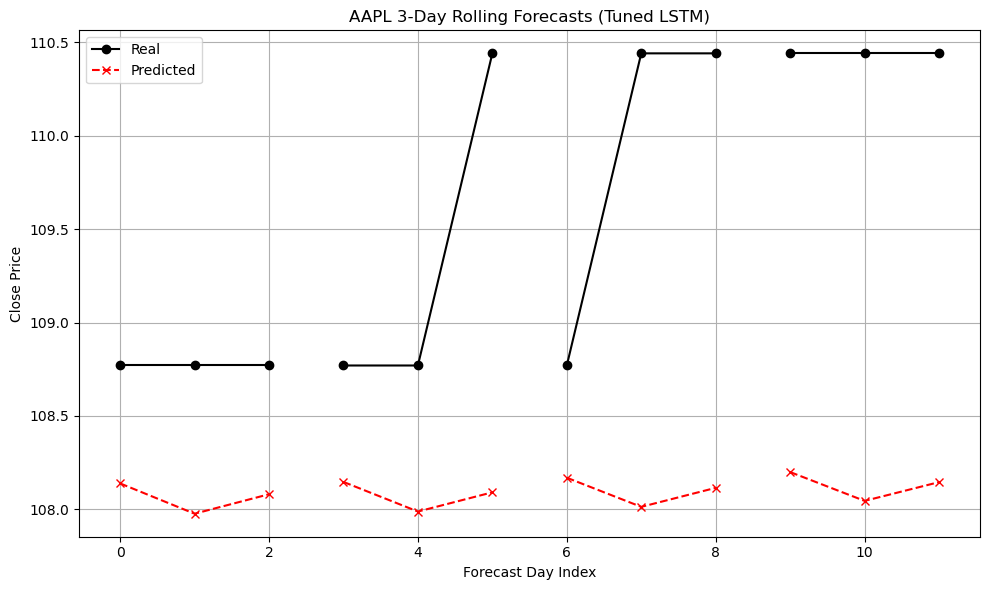

In [251]:
#get rolling forecast plot
n_preds_3d = 4
start_idx_3d = 125

x_test_final_3d = X_3d_test_aapl[start_idx_3d:start_idx_3d + n_preds_3d]
y_test_final_3d = y_3d_test_rescaled_aapl[start_idx_3d:start_idx_3d + n_preds_3d]

predictions_3d_tuned = model_3d_aapl_tuned.predict(x_test_final_3d)
preds_3d_tuned = close_scaler_aapl.inverse_transform(predictions_3d_tuned)

plt.figure(figsize=(10, 6))
for i in range(n_preds_3d):
    x_vals = list(range(i * 3, i * 3 + 3))
    plt.plot(x_vals, y_test_final_3d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_3d_tuned[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('AAPL 3-Day Rolling Forecasts (Tuned LSTM)')
plt.xlabel('Forecast Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [252]:
#save forecast
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_3d_test_rescaled_aapl,
    y_pred_rescaled=y_3d_pred_rescaled_tuned,
    ticker='AAPL',
    model_name='lstm',
    horizon=3,
    window_dates=aapl.index[window_size_aapl:],
    start_idx=split_3d,
    n_preds=len(y_3d_pred_rescaled_tuned),
    tuned=True
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_3d_full_tuned.csv


In [253]:
#save RMSE
rmse_3d_aapl_tuned = np.sqrt(mean_squared_error(y_3d_test_rescaled_aapl, y_3d_pred_rescaled_tuned))

rmse_record_3d = {
    'ticker': 'AAPL',
    'model': 'lstm_tuned',
    'horizon': 3,
    'rmse': rmse_3d_aapl_tuned
}

# add to file
rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame([rmse_record_3d])], ignore_index=True)
else:
    df_rmse = pd.DataFrame([rmse_record_3d])

df_rmse.to_csv(rmse_path, index=False)
print("RMSE summary updated with AAPL 3-day tuned result.")

RMSE summary updated with AAPL 3-day tuned result.


In [254]:
#7 day tuned forecast
def build_model_7d(hp):
    model = Sequential()
    model.add(LSTM(
        units=hp.Int('units', min_value=32, max_value=128, step=32),
        activation='relu',
        input_shape=(window_size_aapl, 2)
    ))
    model.add(Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(7))  # 7-day forecast
    model.compile(optimizer='adam', loss='mse')
    return model

#setting up tuner
tuner_7d = RandomSearch(
    build_model_7d,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=2,
    directory='lstm_tuning',
    project_name='aapl_7d'
)

#running tuner
tuner_7d.search(
    X_7d_train_aapl, y_7d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)],
    verbose=1
)

Reloading Tuner from lstm_tuning\aapl_7d\tuner0.json


In [255]:
#selectig best model from tuner
model_7d_aapl_tuned = tuner_7d.get_best_models(num_models=1)[0]
model_7d_aapl_tuned.summary()
#train
history_7d = model_7d_aapl_tuned.fit(
    X_7d_train_aapl, y_7d_train_aapl,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5)]
)

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 96)                  │          38,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 96)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │             679 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,695 (151.15 KB)

 Trainable params: 38,695 (151.15 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0022 - val_loss: 9.0640e-04
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015 - val_loss: 9.0029e-04
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017 - val_loss: 0.0021
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 8.6992e-04
Epoch 9/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 10/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0014 - val_loss: 8.5811e-04
Epoch 11/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 8.7223e-04
Epoch 12/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

In [256]:
#get predicitions
y_7d_pred_tuned = model_7d_aapl_tuned.predict(X_7d_test_aapl)
y_7d_pred_rescaled_tuned = close_scaler_aapl.inverse_transform(y_7d_pred_tuned)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


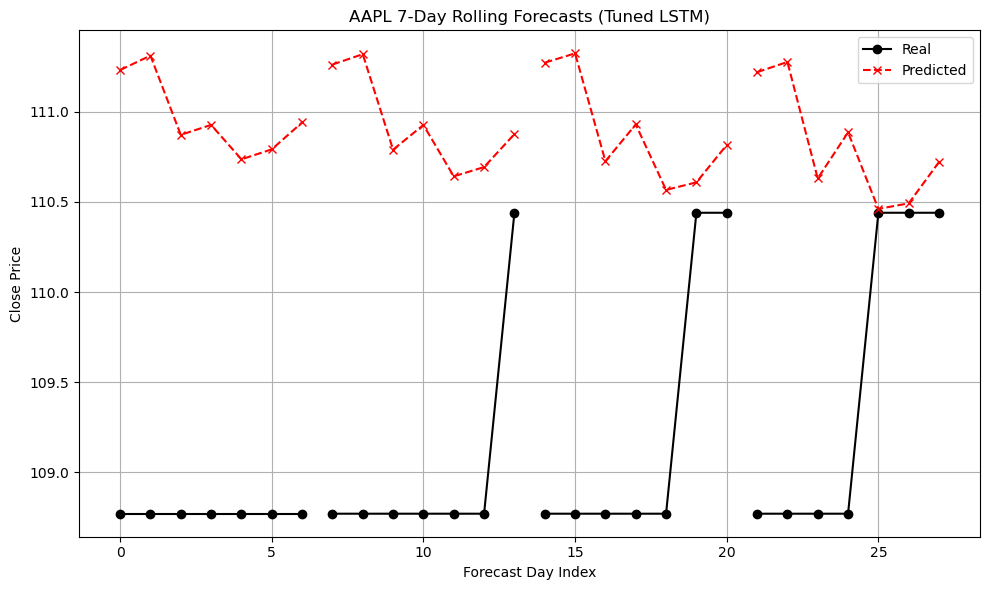

In [257]:
#plot 7 day rolling forecast 
n_preds_7d = 4
start_idx_7d = 125

x_test_final_7d = X_7d_test_aapl[start_idx_7d:start_idx_7d + n_preds_7d]
y_test_final_7d = y_7d_test_rescaled_aapl[start_idx_7d:start_idx_7d + n_preds_7d]

predictions_7d_tuned = model_7d_aapl_tuned.predict(x_test_final_7d)
preds_7d_tuned = close_scaler_aapl.inverse_transform(predictions_7d_tuned)

plt.figure(figsize=(10, 6))
for i in range(n_preds_7d):
    x_vals = list(range(i * 7, i * 7 + 7))
    plt.plot(x_vals, y_test_final_7d[i], color='black', marker='o', label='Real' if i == 0 else "")
    plt.plot(x_vals, preds_7d_tuned[i], color='red', marker='x', linestyle='--', label='Predicted' if i == 0 else "")

plt.title('AAPL 7-Day Rolling Forecasts (Tuned LSTM)')
plt.xlabel('Forecast Day Index')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [258]:
#saving forcast
save_lstm_rolling_forecast_with_stock(
    y_true_rescaled=y_7d_test_rescaled_aapl,
    y_pred_rescaled=y_7d_pred_rescaled_tuned,
    ticker='AAPL',
    model_name='lstm',
    horizon=7,
    window_dates=aapl.index[window_size_aapl:],
    start_idx=split_7d,
    n_preds=len(y_7d_pred_rescaled_tuned),
    tuned=True
)

Saved full timeline with forecast: forecast_exports/AAPL_lstm_7d_full_tuned.csv


In [259]:
#saving RMSE
rmse_7d_aapl_tuned = np.sqrt(mean_squared_error(y_7d_test_rescaled_aapl, y_7d_pred_rescaled_tuned))

rmse_record_7d = {
    'ticker': 'AAPL',
    'model': 'lstm_tuned',
    'horizon': 7,
    'rmse': rmse_7d_aapl_tuned
}
#adding to RMSE file
rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame([rmse_record_7d])], ignore_index=True)
else:
    df_rmse = pd.DataFrame([rmse_record_7d])

df_rmse.to_csv(rmse_path, index=False)
print("RMSE summary updated with AAPL 7-day tuned result.")

RMSE summary updated with AAPL 7-day tuned result.


## Boeing
- stationary, weak sentiment signal (p=0.116) for weekly sentiment at lag 1
- Have over 900 tweets (thrid highest) so will include exogeneous variable

In [261]:
#repeating SARIMAX stuff from earlier
#preparing the data for use with Boeing
ba_df = df_merged[df_merged['ticker'] == 'BA'].copy()

# setting date index
ba_df['date'] = pd.to_datetime(ba_df['date'])
ba_df.set_index('date', inplace=True)

# create lagged sentiment (Granger test said lag=1)
ba_df['sentiment_lag1'] = ba_df['weekly_sentiment'].shift(1)

# keep only necessary columns
merged_ba = ba_df[['close', 'sentiment_lag1']].copy()
merged_ba['sentiment_lag1'] = merged_ba['sentiment_lag1'].fillna(0)

print(merged_ba.head(10))

                 close  sentiment_lag1
date                                  
2019-12-31  325.760010        0.000000
2020-01-02  333.320007        0.000000
2020-01-03  332.760010        0.000000
2020-01-06  333.739990        0.000000
2020-01-07  337.279999        0.015082
2020-01-07  337.279999        0.015082
2020-01-08  331.369995        0.015082
2020-01-09  336.339996        0.015082
2020-01-10  329.920013        0.015082
2020-01-10  329.920013        0.015082


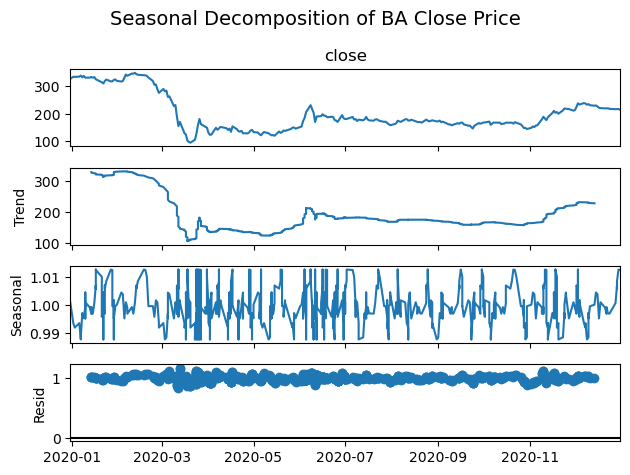

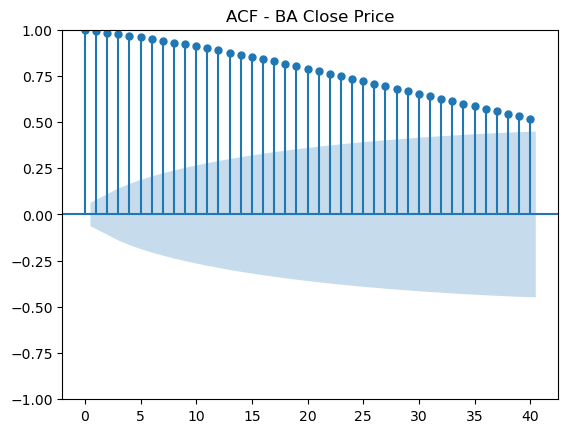

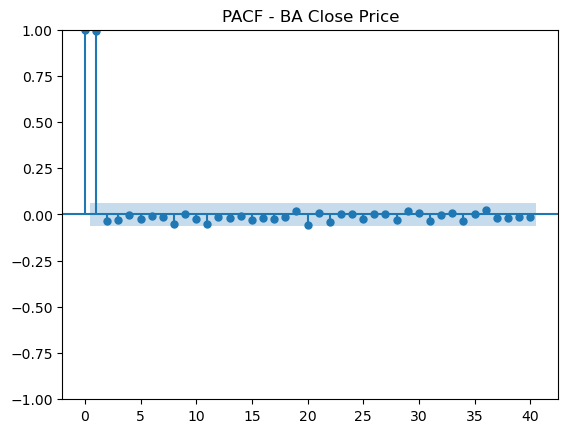

In [262]:
# decomposition so can check for seasonality.. possible with boeing... but maybe more evident annually
decomposition = seasonal_decompose(merged_ba['close'], model='multiplicative', period=30)
decomposition.plot()
plt.suptitle('Seasonal Decomposition of BA Close Price', fontsize=14)
plt.tight_layout()
plt.show()

# ACF & PACF (no differencing here)
plot_acf(merged_ba['close'].dropna(), lags=40)
plt.title('ACF - BA Close Price')
plt.show()

plot_pacf(merged_ba['close'].dropna(), lags=40)
plt.title('PACF - BA Close Price')
plt.show()

PACF suggests p should be 2, q could be 1 or 2...(gradually declining ACF plt) ADF test said it was stationary so should use d=0

In [264]:
#train/test/split
train_ba = merged_ba[merged_ba.index < '2020-11-01']
test_ba = merged_ba[merged_ba.index >= '2020-11-01']

train_close_ba = train_ba['close']
train_exog_ba = train_ba[['sentiment_lag1']]
test_close_ba = test_ba['close']
test_exog_ba = test_ba[['sentiment_lag1']]

In [265]:
#(S)ARIMAX model... didn't note clear seasonality
model_ba = SARIMAX(train_close_ba,
                   exog=train_exog_ba,
                   order=(2, 0, 1), #..could be (2,0,2) either
                   enforce_stationarity=False,
                   enforce_invertibility=False)

results_ba = model_ba.fit(disp=False)
print(results_ba.summary())

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  849
Model:               SARIMAX(2, 0, 1)   Log Likelihood               -4093.866
Date:                Wed, 14 May 2025   AIC                           8197.732
Time:                        21:18:17   BIC                           8221.441
Sample:                             0   HQIC                          8206.815
                                - 849                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
sentiment_lag1  1085.4620     38.463     28.221      0.000    1010.076    1160.848
ar.L1              0.0313      0.171      0.183      0.855      -0.304       0.367
ar.L2              0.9086      0.165

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Forecast (1-day ahead):
date
2020-11-02    142.590364
dtype: float64


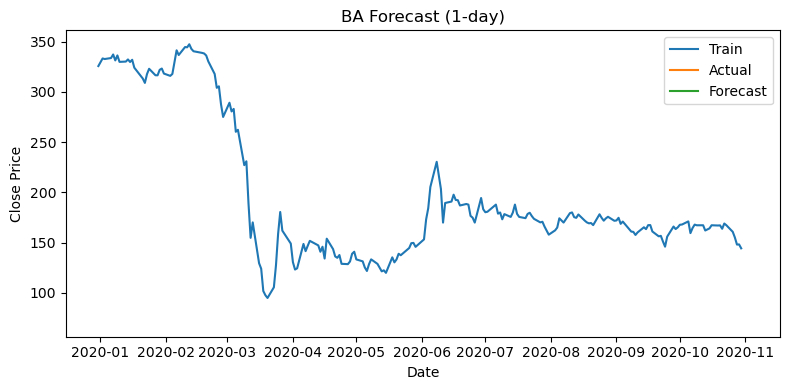


Forecast (3-day ahead):
date
2020-11-02    142.590364
2020-11-03    198.813159
2020-11-04    197.166952
Name: predicted_mean, dtype: float64


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


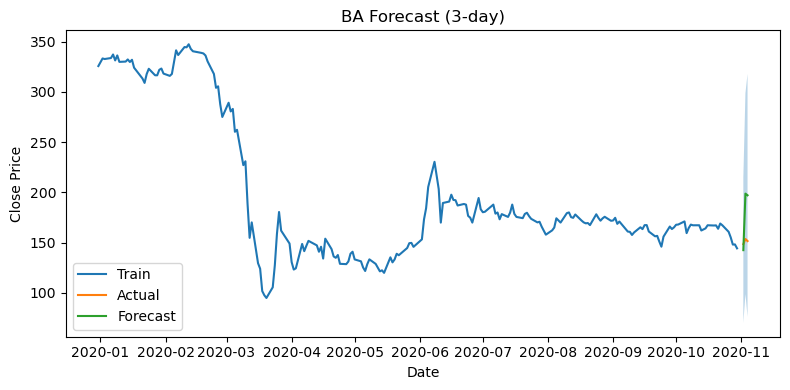


Forecast (7-day ahead):
date
2020-11-02    142.590364
2020-11-03    198.813159
2020-11-04    197.166952
2020-11-05    196.793056
2020-11-06    195.285653
2020-11-09    194.898771
2020-11-09    119.646455
Name: predicted_mean, dtype: float64


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


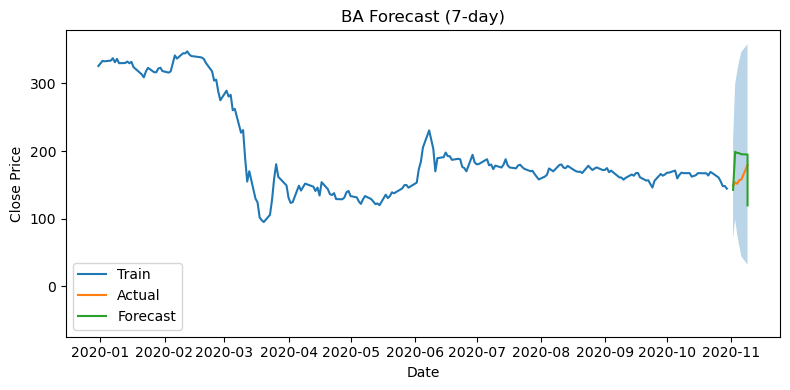

In [266]:
#forcasting and plotting
forecast_steps = [1, 3, 7] #looping through each forecast
train_ba.index = pd.to_datetime(train_ba.index)
test_ba.index = pd.to_datetime(test_ba.index)

for step in forecast_steps:
    pred = results_ba.get_forecast(steps=step, exog=test_exog_ba[:step])
    pred_mean = pred.predicted_mean
    conf_int = pred.conf_int()

    if not isinstance(pred_mean.index, pd.DatetimeIndex):
        pred_mean.index = test_ba.index[:step]
        conf_int.index = test_ba.index[:step]

    print(f"\nForecast ({step}-day ahead):")
    print(pred_mean)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(train_ba.index, train_close_ba, label='Train')
    plt.plot(test_ba.index[:step], test_close_ba[:step], label='Actual')
    plt.plot(pred_mean.index, pred_mean, label='Forecast')
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], alpha=0.3)
    plt.title(f'BA Forecast ({step}-day)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [267]:
#evaluate with RMSE and save forecasts for dashboard
print("\nBA ARIMAX RMSE Scores:")
for step in forecast_steps:
    pred = results_ba.get_forecast(steps=step, exog=test_exog_ba[:step])
    pred_mean = pred.predicted_mean
    actual = test_close_ba[:step]

    rmse = np.sqrt(mean_squared_error(actual, pred_mean))
    print(f"{step}-day RMSE: {rmse:.2f}")

    df_preds = pd.DataFrame({
        'forecast_made_on': [test.index[0]] * step,
        'day_ahead': list(range(1, step + 1)),
        'forecast': pred_mean.values,
        'actual': actual.values
    })

    save_arima_forecast_with_stock(df_preds, 'BA', 'arimax', step)

C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



BA ARIMAX RMSE Scores:
1-day RMSE: 6.01
Saved full timeline with forecast: forecast_exports/BA_arimax_1d_full.csv
3-day RMSE: 37.19
Saved full timeline with forecast: forecast_exports/BA_arimax_3d_full.csv
7-day RMSE: 39.54
Saved full timeline with forecast: forecast_exports/BA_arimax_7d_full.csv


C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\orlak\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_predicti

In [268]:
#saving RMSE
rmse_records = [
    {'ticker': 'BA', 'model': 'arimax', 'horizon': 1, 'rmse': 6.01}, 
    {'ticker': 'BA', 'model': 'arimax', 'horizon': 3, 'rmse': 37.19},
    {'ticker': 'BA', 'model': 'arimax', 'horizon': 7, 'rmse': 39.54},
]

rmse_path = "forecast_exports/rmse_summary.csv"
if os.path.exists(rmse_path):
    df_rmse = pd.read_csv(rmse_path)
    df_rmse = pd.concat([df_rmse, pd.DataFrame(rmse_records)], ignore_index=True)
else:
    df_rmse = pd.DataFrame(rmse_records)

df_rmse.to_csv("forecast_exports/rmse_summary.csv", index=False)
print("RMSE summary updated")


RMSE summary updated


In [269]:
#saving sentiment for Boeing
boeing_sentiment = df_merged[df_merged['ticker'] == 'BA'][['week', 'weekly_sentiment']].dropna()

#drop duplicates just in case
boeing_sentiment = boeing_sentiment.drop_duplicates()

#saving to CSV
boeing_sentiment.to_csv("forecast_exports/BA_sentiment_trend.csv", index=False)
print("Boeing weekly sentiment trend saved")

Boeing weekly sentiment trend saved


<Axes: title={'center': 'TSLA Raw Close Price (no merge)'}, xlabel='date'>

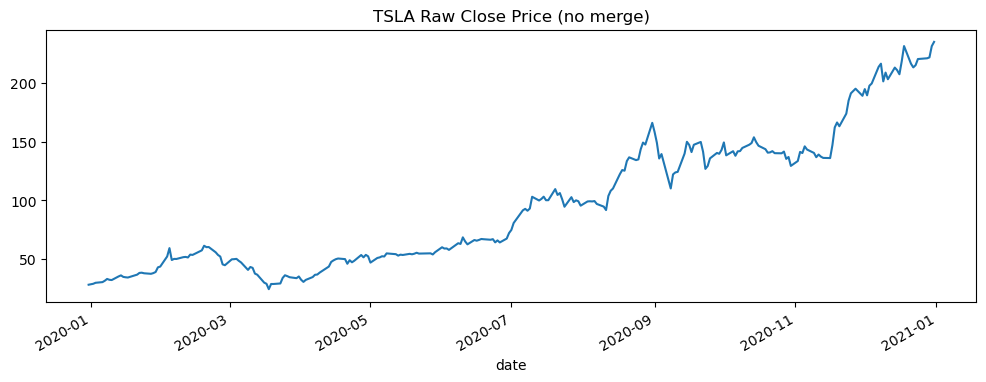

In [270]:
# Check: does df_merged contain stock values on tweet-only dates?
# Look for duplicate dates or flat Close prices

# For TSLA, for example
tsla = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla['date'] = pd.to_datetime(tsla['date'])
tsla.set_index('date', inplace=True)

# Plot just Close price (not joined with tweets)
tsla['close'].plot(figsize=(12,4), title="TSLA Raw Close Price (no merge)")

<Axes: title={'center': 'Number of Rows per Date for TSLA in df_merged'}, xlabel='date'>

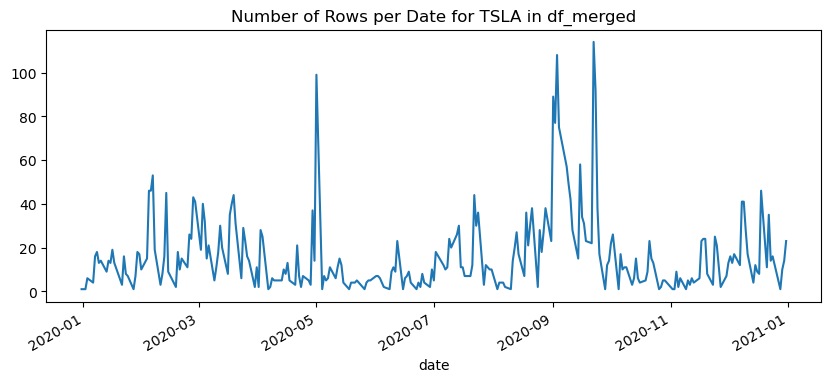

In [271]:
# Group by date and count rows per day (per ticker)
tsla_merged = df_merged[df_merged['ticker'] == 'TSLA'].copy()
tsla_merged['date'] = pd.to_datetime(tsla_merged['date'])
date_counts = tsla_merged.groupby('date').size()

# Plot to see if any dates have more than one entry
date_counts.plot(figsize=(10,4), title="Number of Rows per Date for TSLA in df_merged")